# ETL Pipeline: Scraping DBLP & OpenAlex per la Ricerca di Dataset
**Estrazione, Arricchimento e Validazione di Paper Accademici (2015-2025)**

In questo notebook ho costruito una pipeline ETL (Extract, Transform, Load) completa e automatizzata, progettata per analizzare la letteratura scientifica di tre principali conferenze di Data Mining e Social Web (*KDD, CIKM, ICWSM*) e identificare i paper che introducono nuovi dataset o risorse.

L'architettura segue il paradigma **Medallion (Bronze, Silver, Gold)**:
* **Bronze Layer (Raw Data):** scraping strutturato di DBLP per recuperare metadati di base e link DOI ufficiali.
* **Silver Layer (Enriched Data):** arricchimento tramite le API REST di OpenAlex per recuperare abstract (ricostruiti dall'inverted index), conteggio delle citazioni e stato Open Access.
* **Gold Layer (Validated Data):** filtraggio avanzato dei paper rilevanti, implementato in due versioni — una basata su espressioni regolari e una basata su modelli Transformer in modalità Zero-Shot.

Il notebook si conclude con un'analisi dell'impatto scientifico (Citation Velocity, In-Degree Centrality reale calcolata sul grafo) e una serie di test statistici per confrontare le performance dei paper "Dataset" rispetto al resto della letteratura.

---

### Evoluzione della Pipeline
All'interno dei layer Silver e Gold ho implementato **due approcci** indipendenti:
* **Versione 1 (Moduli 2.5 e 3 - Regex):** primo approccio basato su espressioni regolari e keyword matching. Veloce ma rigido e soggetto a falsi positivi.
* **Versione 2 (Moduli 2.6 e 3.5 - NLP):** approccio evoluto basato sull'inferenza di un modello Transformer (`facebook/bart-large-mnli`) in Zero-Shot Classification. Più costoso computazionalmente ma in grado di distinguere il *contesto semantico* di un paper (ad esempio, separare un paper che *utilizza* un dataset da uno che ne *rilascia* uno nuovo).

Il flusso si conclude con la fase di **Network Analysis (Modulo 5 e 6)**, dove esporto il grafo delle citazioni in formato Gephi e ne calcolo le metriche di centralità direttamente da NetworkX.


etl_pipeline_architecture.svg


<svg width="100%" viewBox="0 0 760 400" role="img" xmlns="http://www.w3.org/2000/svg">
  <title>ETL pipeline architecture</title>
  <defs>
    <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
      <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
    </marker>
  </defs>
  <!-- BRONZE -->
  <g style="font-family:'Segoe UI', sans-serif;">
    <rect x="10" y="30" width="170" height="280" rx="14" style="fill:rgb(99, 56, 6);stroke:rgb(239, 159, 39);stroke-width:0.5px;"/>
    <text x="95" y="60" text-anchor="middle" style="fill:rgb(250, 199, 117);font-size:14px;font-weight:600;">Bronze layer</text>
    <text x="95" y="78" text-anchor="middle" style="fill:rgb(239, 159, 39);font-size:12px;">DBLP ingestion</text>
    <rect x="25" y="94" width="140" height="44" rx="6" style="fill:rgb(68, 68, 65);stroke:rgb(180, 178, 169);stroke-width:0.5px;"/>
    <text x="95" y="112" text-anchor="middle" style="fill:rgb(211, 209, 199);font-size:13px;font-weight:600;">Mod. 1</text>
    <text x="95" y="128" text-anchor="middle" style="fill:rgb(180, 178, 169);font-size:11px;">BeautifulSoup crawler</text>
    <rect x="25" y="150" width="140" height="44" rx="6" style="fill:rgb(68, 68, 65);stroke:rgb(180, 178, 169);stroke-width:0.5px;"/>
    <text x="95" y="168" text-anchor="middle" style="fill:rgb(211, 209, 199);font-size:13px;font-weight:600;">Mod. 1.5</text>
    <text x="95" y="184" text-anchor="middle" style="fill:rgb(180, 178, 169);font-size:11px;">EDA &amp; categorie</text>
  </g>
  <!-- Arrow Bronze -> Silver -->
  <line x1="180" y1="170" x2="215" y2="170" marker-end="url(#arrow)" style="fill:none;stroke:rgb(156, 154, 146);stroke-width:1.5px;"/>
  <text x="197" y="162" text-anchor="middle" style="fill:rgb(194, 192, 182);font-family:'Segoe UI', sans-serif;font-size:11px;">CSV</text>
  <!-- SILVER -->
  <g style="font-family:'Segoe UI', sans-serif;">
    <rect x="215" y="30" width="220" height="280" rx="14" style="fill:rgb(8, 80, 65);stroke:rgb(93, 202, 165);stroke-width:0.5px;"/>
    <text x="325" y="60" text-anchor="middle" style="fill:rgb(159, 225, 203);font-size:14px;font-weight:600;">Silver layer</text>
    <text x="325" y="78" text-anchor="middle" style="fill:rgb(93, 202, 165);font-size:12px;">OpenAlex enrichment</text>
    <rect x="230" y="94" width="190" height="44" rx="6" style="fill:rgb(68, 68, 65);stroke:rgb(180, 178, 169);stroke-width:0.5px;"/>
    <text x="325" y="112" text-anchor="middle" style="fill:rgb(211, 209, 199);font-size:13px;font-weight:600;">Mod. 2</text>
    <text x="325" y="128" text-anchor="middle" style="fill:rgb(180, 178, 169);font-size:11px;">Abstract + citazioni</text>
    <rect x="230" y="150" width="90" height="60" rx="6" style="fill:rgb(68, 68, 65);stroke:rgb(180, 178, 169);stroke-width:0.5px;stroke-dasharray:3,3;"/>
    <text x="275" y="170" text-anchor="middle" style="fill:rgb(211, 209, 199);font-size:12px;font-weight:600;">Mod. 2.5</text>
    <text x="275" y="186" text-anchor="middle" style="fill:rgb(180, 178, 169);font-size:10px;">Regex (V1)</text>
    <rect x="330" y="150" width="90" height="60" rx="6" style="fill:rgb(68, 68, 65);stroke:rgb(180, 178, 169);stroke-width:0.5px;"/>
    <text x="375" y="170" text-anchor="middle" style="fill:rgb(211, 209, 199);font-size:12px;font-weight:600;">Mod. 2.6</text>
    <text x="375" y="186" text-anchor="middle" style="fill:rgb(180, 178, 169);font-size:10px;">NLP (V2)</text>
  </g>
  <!-- Arrow Silver -> Gold -->
  <line x1="435" y1="170" x2="470" y2="170" marker-end="url(#arrow)" style="fill:none;stroke:rgb(156, 154, 146);stroke-width:1.5px;"/>
  <text x="452" y="162" text-anchor="middle" style="fill:rgb(194, 192, 182);font-family:'Segoe UI', sans-serif;font-size:11px;">CSV</text>
  <!-- GOLD -->
  <g style="font-family:'Segoe UI', sans-serif;">
    <rect x="470" y="30" width="170" height="280" rx="14" style="fill:rgb(76, 29, 149);stroke:rgb(167, 139, 250);stroke-width:0.5px;"/>
    <text x="555" y="60" text-anchor="middle" style="fill:rgb(196, 181, 253);font-size:14px;font-weight:600;">Gold layer</text>
    <text x="555" y="78" text-anchor="middle" style="fill:rgb(167, 139, 250);font-size:12px;">Validated datasets</text>
    <rect x="485" y="94" width="140" height="50" rx="6" style="fill:rgb(68, 68, 65);stroke:rgb(180, 178, 169);stroke-width:0.5px;stroke-dasharray:3,3;"/>
    <text x="555" y="114" text-anchor="middle" style="fill:rgb(211, 209, 199);font-size:13px;font-weight:600;">Mod. 3 (V1)</text>
    <text x="555" y="130" text-anchor="middle" style="fill:rgb(180, 178, 169);font-size:11px;">Filtro Regex</text>
    <rect x="485" y="156" width="140" height="50" rx="6" style="fill:rgb(68, 68, 65);stroke:rgb(180, 178, 169);stroke-width:0.5px;"/>
    <text x="555" y="176" text-anchor="middle" style="fill:rgb(211, 209, 199);font-size:13px;font-weight:600;">Mod. 3.5 (V2)</text>
    <text x="555" y="192" text-anchor="middle" style="fill:rgb(180, 178, 169);font-size:11px;">Filtro NLP</text>
  </g>
  <!-- Arrow Gold -> Analysis -->
  <line x1="640" y1="170" x2="675" y2="170" marker-end="url(#arrow)" style="fill:none;stroke:rgb(156, 154, 146);stroke-width:1.5px;"/>
  <!-- ANALYSIS column -->
  <g style="font-family:'Segoe UI', sans-serif;">
    <rect x="675" y="30" width="75" height="280" rx="14" style="fill:rgb(20, 83, 45);stroke:rgb(74, 222, 128);stroke-width:0.5px;"/>
    <text x="712" y="60" text-anchor="middle" style="fill:rgb(187, 247, 208);font-size:13px;font-weight:600;">Analysis</text>
    <text x="712" y="100" text-anchor="middle" style="fill:rgb(187, 247, 208);font-size:11px;">Mod. 4</text>
    <text x="712" y="118" text-anchor="middle" style="fill:rgb(74, 222, 128);font-size:10px;">EDA + Stats</text>
    <text x="712" y="148" text-anchor="middle" style="fill:rgb(187, 247, 208);font-size:11px;">Mod. 5</text>
    <text x="712" y="166" text-anchor="middle" style="fill:rgb(74, 222, 128);font-size:10px;">Gephi export</text>
    <text x="712" y="196" text-anchor="middle" style="fill:rgb(187, 247, 208);font-size:11px;">Mod. 6</text>
    <text x="712" y="214" text-anchor="middle" style="fill:rgb(74, 222, 128);font-size:10px;">Network</text>
  </g>
  <!-- Legend dashed/solid -->
  <g style="font-family:'Segoe UI', sans-serif;">
    <text x="20" y="345" style="fill:rgb(194, 192, 182);font-size:11px;">Legenda:</text>
    <line x1="80" y1="342" x2="120" y2="342" style="stroke:rgb(180, 178, 169);stroke-width:1.5px;stroke-dasharray:3,3;"/>
    <text x="125" y="346" style="fill:rgb(180, 178, 169);font-size:11px;">V1 (Regex)</text>
    <line x1="200" y1="342" x2="240" y2="342" style="stroke:rgb(180, 178, 169);stroke-width:1.5px;"/>
    <text x="245" y="346" style="fill:rgb(180, 178, 169);font-size:11px;">V2 (NLP) — versione definitiva</text>
  </g>
</svg>


## Modulo 0: Setup ambiente e directory di progetto

In questa cella inizializzo l'ambiente di lavoro. Monto Google Drive per garantire la persistenza dei dati tra una sessione di Colab e l'altra, e definisco la struttura di cartelle del progetto:
* `ScrapingDBLP_final/` è la cartella radice del progetto.
* `ScrapingDBLP_final/final_pdfs/` è la sotto-cartella dove caricherò manualmente i PDF finali (relazione, screenshot di Gephi, esportazioni di grafici).
* All'interno della cartella radice salvo tutti i CSV intermedi e finali della pipeline, numerati in modo da rispettare l'ordine della Medallion Architecture.


In [ ]:
# ==============================================================================
# MODULO 0: SETUP AMBIENTE E DIRECTORY DI PROGETTO
# ==============================================================================
# Inizializzo l'ambiente, monto Google Drive e creo la struttura di cartelle.

import os
from google.colab import drive

# 1. Mount di Google Drive (richiede autorizzazione una volta a sessione)
drive.mount('/content/drive')

# 2. Definisco la cartella radice del progetto e la sotto-cartella per i PDF
BASE_DIR = '/content/drive/MyDrive/ScrapingDBLP_final'
PDF_DIR  = os.path.join(BASE_DIR, 'final_pdfs')

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(PDF_DIR,  exist_ok=True)

# 3. Definisco i percorsi dei CSV della pipeline
BRONZE_CSV_PATH      = os.path.join(BASE_DIR, '01_bronze_dblp_raw.csv')
SILVER_CSV_PATH      = os.path.join(BASE_DIR, '02_silver_openalex_enriched.csv')
SILVER_NLP_CSV_PATH  = os.path.join(BASE_DIR, '02_5_silver_nlp_enriched.csv')
GOLD_REGEX_CSV_PATH  = os.path.join(BASE_DIR, '03_gold_regex_validated.csv')
GOLD_NLP_CSV_PATH    = os.path.join(BASE_DIR, '03_5_gold_nlp_validated.csv')
EDGES_CSV_PATH       = os.path.join(BASE_DIR, '05_citation_network_edges.csv')
NODES_CSV_PATH       = os.path.join(BASE_DIR, '05_citation_network_nodes.csv')

print(f"[SETUP] Cartella progetto:   {BASE_DIR}")
print(f"[SETUP] Cartella PDF finali: {PDF_DIR}")
print(f"[SETUP] Tutti i percorsi sono configurati e pronti.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[SETUP] Cartella progetto:   /content/drive/MyDrive/ScrapingDBLP_final
[SETUP] Cartella PDF finali: /content/drive/MyDrive/ScrapingDBLP_final/final_pdfs
[SETUP] Tutti i percorsi sono configurati e pronti.


## Modulo 0.5: Stile e palette dei grafici

Seguendo le linee guida della lezione di *data visualization* (stile coerente — "crea il tuo brand" — e palette sicure per il daltonismo) centralizzo qui **una sola** palette riusata da tutti i grafici del notebook. In questo modo i colori sono coerenti tra le figure: ogni conferenza ha sempre lo stesso colore (KDD/CIKM/ICWSM), i confronti binari (Con/Senza Dataset, Media/Mediana) usano sempre la stessa coppia, e le metriche continue (centralità) usano la scala percettivamente uniforme **Viridis**.

I colori provengono dalla palette **Okabe–Ito**, progettata per essere distinguibile anche da chi ha deficit di visione dei colori (niente coppie rosso/verde).


In [ ]:
# ==============================================================================
# MODULO 0.5: PALETTE E TEMA GRAFICI (centralizzati e coerenti)
# ==============================================================================
import plotly.io as pio
import plotly.express as px

# Colore FISSO per ogni conferenza: identico in tutti i grafici (palette Okabe-Ito)
CONF_COLORS = {
    'KDD':   '#0072B2',  # blu
    'CIKM':  '#E69F00',  # arancione
    'ICWSM': '#009E73',  # verde acqua
}

# Coppia per i confronti binari (Con/Senza Dataset, Media/Mediana, periodi)
BINARY_COLORS = ['#0072B2', '#D55E00']  # blu / vermiglio (sicuri per daltonismo)

# Scala sequenziale per metriche continue (centralita') — raccomandata nella lezione
SEQ_SCALE = 'Viridis'

# Tema di default coerente per ogni figura
pio.templates.default = 'plotly_white'
print('[STILE] Palette e tema grafici configurati.')


[STILE] Palette e tema grafici configurati.


## Modulo 1: Scraping DBLP (Bronze Layer)

In questa fase scarico il contenuto HTML delle pagine indice di DBLP e ne estraggo i metadati grezzi (titolo, anno, conferenza, DOI, traccia editoriale). Per blindare il processo ho implementato:

1. **Whitelisting con Regex** sui nomi dei volumi: voglio solo le edizioni *Main Conference* della finestra 2015-2025, scartando workshop, satelliti e CEUR proceedings.
2. **Backoff esponenziale** in caso di errore 503 (rate limiting di DBLP): la pausa cresce progressivamente a ogni tentativo fallito.
3. **Estrazione contestuale della categoria**: scorrendo la pagina HTML, ogni paper viene associato al suo header di sezione più vicino (es. "Dataset Track", "Applied Data Science Track"). Questa informazione è preziosa per il filtraggio successivo.


In [ ]:
# ==============================================================================
# MODULO 1: ESTRAZIONE DBLP (LIVELLO BRONZE)  - COMPATIBILE CON MODULO 1.5
# ==============================================================================
# Questo modulo gestisce lo scraping strutturato da DBLP per recuperare metadati
# e link DOI ufficiali delle conferenze target, isolando in modo specifico le
# pubblicazioni della Main Track.

import os
import re
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup

# --- PROTOCOLLO DI CONFIGURAZIONE ---
INDICI_CONFERENZE = {
    "ICWSM": "https://dblp.org/db/conf/icwsm/index.html",
    "CIKM":  "https://dblp.org/db/conf/cikm/index.html",
    "KDD":   "https://dblp.org/db/conf/kdd/index.html"
}

# Range temporale di analisi
ANNI_TARGET = [str(anno) for anno in range(2015, 2026)]
BRONZE_CSV_PATH = '/content/drive/MyDrive/Dataset_Research_Project/01_bronze_dblp_raw.csv'

# ------------------------------------------------------------------------------
# FUNZIONI PRINCIPALI
# ------------------------------------------------------------------------------

def fetch_with_retry(session: requests.Session, url: str, max_retries: int = 5):
    """
    Esegue una richiesta HTTP GET utilizzando un meccanismo anti-blocco tramite
    backoff lineare progressivo (pausa = 10*(tentativo+1) s).

    Parametri:
    - session (requests.Session): Sessione HTTP attiva.
    - url (str): URL target per il recupero dei dati.
    - max_retries (int): Numero massimo di tentativi consentiti in caso di fallimento.

    Ritorna:
    - requests.Response in caso di successo, None altrimenti.
    """
    for attempt in range(max_retries):
        try:
            response = session.get(url, timeout=15)
            # Recupero completato con successo
            if response.status_code == 200:
                return response
            # Rate Limit DBLP (HTTP 503): Applica sospensione progressiva
            elif response.status_code == 503:
                pausa = 10 * (attempt + 1)
                print(f"  [RETRY] Rate limit HTTP 503 riscontrato su {url}. "
                      f"Sospensione esecuzione per {pausa}s (Tentativo {attempt+1}/{max_retries})...")
                time.sleep(pausa)
            # Errori HTTP non gestiti (es. 404): Interrompe il ciclo
            else:
                print(f"  [ERRORE] Status Code HTTP {response.status_code} inaspettato per {url}.")
                break
        except requests.exceptions.RequestException as e:
            print(f"  [ECCEZIONE DI RETE] Fallimento connessione. Nuovo tentativo in 5s: {e}")
            time.sleep(5)

    return None


def get_conference_urls(session: requests.Session, indici: dict, anni: list) -> list:
    """
    Analizza le pagine indice delle conferenze per individuare dinamicamente gli URL
    esatti corrispondenti ai volumi annuali della Main Conference.

    Implementa una logica di filtraggio bipartita:
    1. Blacklist: Scarta esplicitamente eventi periferici (es. workshop, CEUR).
    2. Whitelist: Convalida le strutture canoniche dei volumi tramite Espressioni Regolari.
    """
    urls_trovate = set()
    print("[CRAWLER] Inizio protocollo di mappatura delle edizioni Main Track (2015-2025)...")

    for conf_name, index_url in indici.items():
        response = fetch_with_retry(session, index_url)
        if not response:
            continue

        soup = BeautifulSoup(response.content, "html.parser")
        c_low = conf_name.lower() # Normalizza l'acronimo della conferenza per il parsing regex (es. 'kdd')

        for link in soup.find_all("a", class_="toc-link"):
            href = link.get("href")
            if not href or not href.endswith('.html'):
                continue

            testo_link = link.get_text().lower()

            # FILTRO 1: Blacklist di sicurezza
            if any(bad_keyword in testo_link for bad_keyword in ["workshop", "companion", "ceur", "evalrs"]):
                continue

            # FILTRO 2: Whitelist (Verifica anno e validazione Regex del path)
            for anno in anni:
                if anno in href:
                    # Cerca i pattern canonici (es. kdd2020.html o kdd2020-1.html)
                    pattern_main = rf"{c_low}{anno}(-[0-9]+)?\.html$"
                    if re.search(pattern_main, href):
                        urls_trovate.add((conf_name, anno, href))

        # Applica un ritardo di cortesia tra domini di conferenze distinte
        time.sleep(5)

    urls_ordinate = sorted(list(urls_trovate), key=lambda x: (x[0], x[1]), reverse=True)
    print(f"[CRAWLER] Mappatura completata: identificati {len(urls_ordinate)} volumi validi.")
    return urls_ordinate


def extract_all_papers_from_dblp(session: requests.Session, urls: list) -> pd.DataFrame:
    """
    Analizza iterativamente il contenuto HTML dei volumi delle conferenze per estrarre
    i titoli dei paper, le tracce di categorizzazione DBLP e i record DOI standardizzati.
    Ritorna un DataFrame allineato allo schema del Modulo 1.5.
    """
    all_papers = []
    print(f"\n[BRONZE] Avvio estrazione iterativa su {len(urls)} volumi. "
          f"(Vincolo: Ritardo rigoroso di 5s tra le richieste)")

    for conf_name, year, url in urls:
        response = fetch_with_retry(session, url)
        if not response:
            continue

        soup = BeautifulSoup(response.content, "html.parser")
        current_category = "General/Uncategorized"
        estratti_volume = 0

        # DBLP utilizza i nodi h2/h3 per la delineazione delle sezioni (es. "Research Track")
        # e li class="entry" per le singole pubblicazioni. È richiesto l'attraversamento sequenziale.
        for element in soup.find_all(['h2', 'h3', 'li']):

            if element.name in ['h2', 'h3']:
                current_category = element.get_text(strip=True)

            elif element.name == 'li' and 'entry' in element.get('class', []):
                title_tag = element.find(class_="title")
                nav_tag = element.find("nav", class_="publ")

                if title_tag and nav_tag:
                    a_tag = nav_tag.find("a")
                    link_originale = a_tag.get("href") if a_tag else None

                    # Isola i riferimenti DOI standard per la riproducibilità scientifica
                    doi_valido = link_originale if link_originale and "doi.org" in link_originale else None
                    titolo_pulito = title_tag.get_text(strip=True).rstrip('.')

                    # SCHEMA ALLINEATO CON IL MODULO 1.5
                    all_papers.append({
                        "Conferenza": conf_name,
                        "Anno": int(year),
                        "Categoria": current_category,
                        "Titolo": titolo_pulito,
                        "DOI": doi_valido
                    })
                    estratti_volume += 1

        print(f"  - Estratti {estratti_volume:4d} paper da {conf_name} {year}")
        time.sleep(5) # Sospensione rigorosa per prevenire il blocco dell'IP

    return pd.DataFrame(all_papers)

## Modulo 1.0: Identificazione cortese e `robots.txt`

Prima di iniziare lo scraping definisco due accorgimenti di *netiquette* che la lezione sullo scraping raccomanda esplicitamente.

**1. User-Agent.** Ogni richiesta HTTP porta con sé un header `User-Agent` che identifica chi sta scrivendo. Per default `requests` invia una stringa anonima da libreria: molti server la trattano con sospetto o la bloccano. Imposto quindi uno `User-Agent` descrittivo con la mia email di contatto, così l'amministratore di DBLP sa chi sta interrogando il sito e come raggiungermi. La stessa logica del `mailto` che già uso per il *polite pool* di OpenAlex.

**2. `robots.txt`.** È un file di testo standard che ogni sito pubblica alla radice (es. `https://dblp.org/robots.txt`). Contiene le regole che indicano ai bot quali percorsi possono o non possono visitare. Controllarlo *prima* di scrapare è la regola di base dello scraping etico: rispetto le indicazioni del sito ed evito di toccare aree vietate. Uso il modulo standard `urllib.robotparser` per leggerlo e verificare che i percorsi che mi servono (`/db/conf/...`) siano effettivamente consentiti.


In [ ]:
# ==============================================================================
# MODULO 1.0: USER-AGENT + VERIFICA robots.txt
# ==============================================================================
import urllib.robotparser as urobot

# User-Agent descrittivo: identifica lo scraper e fornisce un contatto.
USER_AGENT = (
    "ScrapingDBLP-ResearchProject/1.0 "
    "(+mailto:your-email@example.com)"
)
HEADERS = {"User-Agent": USER_AGENT}


def check_robots_txt(base_url: str, paths: list, user_agent: str = USER_AGENT) -> bool:
    """
    Legge il robots.txt del sito e verifica che lo user-agent possa accedere ai path.
    Ritorna True se TUTTI i path sono consentiti (o se il robots.txt non e' leggibile).
    """
    rp = urobot.RobotFileParser()
    robots_url = base_url.rstrip('/') + '/robots.txt'
    rp.set_url(robots_url)
    try:
        rp.read()
    except Exception as e:
        print(f"  [robots] Impossibile leggere {robots_url} ({e}). Procedo con cautela.")
        return True

    print(f"[robots] Regole lette da {robots_url}")
    tutti_ok = True
    for p in paths:
        ok = rp.can_fetch(user_agent, base_url.rstrip('/') + p)
        stato = 'CONSENTITO' if ok else 'VIETATO'
        print(f"  [robots] {p:<22} -> {stato}")
        tutti_ok = tutti_ok and ok
    return tutti_ok


# Verifico i percorsi delle index page delle conferenze target
PERCORSI_TARGET = ['/db/conf/kdd/', '/db/conf/cikm/', '/db/conf/icwsm/']
scraping_consentito = check_robots_txt('https://dblp.org', PERCORSI_TARGET)
print(f"\n[robots] Scraping consentito su tutti i percorsi target: {scraping_consentito}")


[robots] Regole lette da https://dblp.org/robots.txt
  [robots] /db/conf/kdd/          -> CONSENTITO
  [robots] /db/conf/cikm/         -> CONSENTITO
  [robots] /db/conf/icwsm/        -> CONSENTITO

[robots] Scraping consentito su tutti i percorsi target: True


In [ ]:

# ==============================================================================
# AMBIENTE DI ESECUZIONE DEL MODULO 1
# ==============================================================================
if __name__ == "__main__":
    # Inizializza una sessione HTTP persistente per ottimizzare l'overhead di connessione
    http_session = requests.Session()
    http_session.headers.update(HEADERS)  # identificazione cortese verso DBLP

    # Step 1: Individuazione URL dei volumi
    target_urls = get_conference_urls(http_session, INDICI_CONFERENZE, ANNI_TARGET)

    # Step 2: Estrazione dei dati e Serializzazione I/O
    if target_urls:
        df_bronze = extract_all_papers_from_dblp(http_session, target_urls)

        # Assicura che la directory di destinazione esista prima delle operazioni di scrittura
        os.makedirs(os.path.dirname(BRONZE_CSV_PATH), exist_ok=True)
        df_bronze.to_csv(BRONZE_CSV_PATH, index=False)

        print("\n" + "="*60)
        print(f"[LIVELLO BRONZE] Esecuzione della pipeline completata con successo.")
        print(f"  ▶ Totale Record Serializzati: {len(df_bronze)}")
        print(f"  ▶ Directory di Output: {BRONZE_CSV_PATH}")
        print("="*60)

        # Visualizzazione standard del DataFrame per ambienti Jupyter/Colab
        display(df_bronze.head())

[CRAWLER] Inizio protocollo di mappatura delle edizioni Main Track (2015-2025)...
[CRAWLER] Mappatura completata: identificati 34 volumi validi.

[BRONZE] Avvio estrazione iterativa su 34 volumi. (Vincolo: Ritardo rigoroso di 5s tra le richieste)
  - Estratti  595 paper da KDD 2025
  - Estratti  251 paper da KDD 2025
  - Estratti  643 paper da KDD 2024
  - Estratti  565 paper da KDD 2023
  - Estratti  535 paper da KDD 2022
  - Estratti  483 paper da KDD 2021
  - Estratti  422 paper da KDD 2020
  - Estratti  375 paper da KDD 2019
  - Estratti  311 paper da KDD 2018
  - Estratti  233 paper da KDD 2017
  - Estratti  237 paper da KDD 2016
  - Estratti  254 paper da KDD 2015
  - Estratti  171 paper da ICWSM 2025
  - Estratti  162 paper da ICWSM 2024
  - Estratti  109 paper da ICWSM 2023
  - Estratti  137 paper da ICWSM 2022
  - Estratti  103 paper da ICWSM 2021
  - Estratti  100 paper da ICWSM 2020
  - Estratti   69 paper da ICWSM 2019
  - Estratti  101 paper da ICWSM 2018
  - Estratti  119

,Conferenza,Anno,Categoria,Titolo,DOI
0,KDD,2025,Refine list,Proceedings of the 31st ACM SIGKDD Conference ...,https://doi.org/10.1145/3711896
1,KDD,2025,Keynote Talks,The Surprising Victory of NLP: From Philosophy...,https://doi.org/10.1145/3711896.3736801
2,KDD,2025,Keynote Talks,"On Reasoning LLMs: Myths, Merits, and How to M...",https://doi.org/10.1145/3711896.3736800
3,KDD,2025,Keynote Talks,Causality - Exploiting Multi-Modal Data,https://doi.org/10.1145/3711896.3736799
4,KDD,2025,Research Track,K-Paths: Reasoning over Graph Paths for Drug R...,https://doi.org/10.1145/3711896.3737011


## Modulo 1.5: Analisi esplorativa e consolidamento del Bronze Layer

Su questi dati grezzi eseguo tre operazioni:

1. **Data profiling**: analizzo la copertura dei DOI e il trend di pubblicazione decennale.
2. **Normalizzazione delle categorie**: DBLP usa decine di etichette di sezione frammentate (es. "Session 7A: Data Streams", "Applied Data Track 2020"); le riduco a una macro-tassonomia di sei livelli per rendere il filtraggio successivo robusto.
3. **Riordino e salvataggio**: pulisco le colonne, le riordino in modo coerente e salvo il CSV consolidato che alimenta il Silver Layer.

### Sulla copertura DOI di ICWSM
Dall'analisi emerge un'anomalia strutturale: CIKM e KDD hanno copertura DOI vicino al 100% mentre ICWSM si attesta intorno al 30-35%. Non è un bug dello scraper: KDD e CIKM sono pubblicate da **ACM**, che assegna sistematicamente DOI a ogni paper della Digital Library, mentre ICWSM è pubblicata da **AAAI**, che storicamente ha distribuito i proceeding in Open Access senza assegnare DOI rigorosamente (pratica adottata in modo sistematico solo nelle edizioni più recenti).
Per i paper ICWSM sprovvisti di DOI il Silver Layer tenterà comunque il recupero tramite ricerca per titolo esatto su OpenAlex.


In [ ]:
# ==============================================================================
# MODULO 1.5: EDA, NORMALIZZAZIONE CATEGORIE E CONSOLIDAMENTO
# ==============================================================================
# Eseguo profiling sul Bronze Layer, normalizzo la tassonomia delle track e
# riordino le colonne per produrre la versione definitiva del Bronze CSV.

import re
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------------------------
# FUNZIONE: profiling dei dati estratti
# ------------------------------------------------------------------------------
def profile_bronze_data(df: pd.DataFrame) -> None:
    """
    Stampo statistiche di base: copertura DOI complessiva e per conferenza,
    e volumi di pubblicazione anno per anno.
    """
    total = len(df)
    print("[EDA] " + "=" * 50)
    print("[EDA] 1. COPERTURA DOI")
    print("[EDA] " + "=" * 50)

    with_doi = df['DOI'].notna().sum()
    print(f"  Totale record:    {total}")
    print(f"  Con DOI:          {with_doi} ({with_doi/total*100:.2f}%)")
    print(f"  Senza DOI:        {total-with_doi} ({(total-with_doi)/total*100:.2f}%)\n")

    print("[EDA] Copertura DOI per conferenza:")
    doi_by_conf = df.groupby('Conferenza')['DOI'].apply(
        lambda x: (x.notna().sum() / len(x)) * 100
    ).round(2)
    for conf, perc in doi_by_conf.items():
        print(f"  - {conf}: {perc}%")

    print("\n[EDA] " + "=" * 50)
    print("[EDA] 2. VOLUMI DI PUBBLICAZIONE PER ANNO")
    print("[EDA] " + "=" * 50)
    trend = pd.pivot_table(df, values='Titolo', index='Anno',
                           columns='Conferenza', aggfunc='count', fill_value=0)
    trend['Totale_Anno'] = trend.sum(axis=1)
    display(trend.sort_index(ascending=False))


# ------------------------------------------------------------------------------
# FUNZIONE: normalizzazione delle categorie DBLP
# ------------------------------------------------------------------------------
def normalize_category(cat_string: str) -> str:
    """
    Converto le decine di etichette frammentate di DBLP in una tassonomia
    compatta di sei macro-categorie. La logica è ordinata per priorità:
    le track più specifiche (Dataset/Resource) vincono su quelle generiche.
    """
    if not isinstance(cat_string, str):
        return "Uncategorized"

    cat = cat_string.lower().replace('\n', ' ')

    # Rimuovo prefissi numerici ('Session 7A:') e riferimenti alla conferenza
    cat = re.sub(r'session\s*[0-9a-z]+:', '', cat)
    cat = re.sub(r'(kdd|cikm|icwsm)\s*\'?\d{2,4}', '', cat)
    cat = cat.strip()

    if any(w in cat for w in ['dataset', 'benchmark']):
        return 'Dataset Track'
    if any(w in cat for w in ['resource', 'tool', 'software']):
        return 'Resource/Tools Track'
    if any(w in cat for w in ['applied', 'industry', 'ads track']):
        return 'Applied/Industry Track'
    if 'short' in cat:
        return 'Short Papers'
    if 'poster' in cat:
        return 'Poster Papers'
    if 'demo' in cat:
        return 'Demo Papers'
    if any(w in cat for w in ['keynote', 'tutorial', 'invited']):
        return 'Keynotes & Tutorials'
    return 'Main/Research Track'


def clean_categories(df: pd.DataFrame) -> pd.DataFrame:
    """Applico la funzione di normalizzazione e mostro la distribuzione finale."""
    df = df.copy()
    df['Categoria'] = df['Categoria'].apply(normalize_category)
    print("\n[CLEAN] Distribuzione delle macro-categorie:")
    print(df['Categoria'].value_counts().to_string())
    return df


# ------------------------------------------------------------------------------
# FUNZIONE: riordino e salvataggio del Bronze consolidato
# ------------------------------------------------------------------------------
def reorder_and_save(df: pd.DataFrame, path: str) -> pd.DataFrame:
    """Riordino le colonne e salvo il CSV definitivo del Bronze Layer."""
    cols_order = ['Conferenza', 'Anno', 'Categoria', 'Titolo', 'DOI']
    df = df[cols_order].copy()
    df.to_csv(path, index=False)
    print(f"\n[CONSOLIDAMENTO] Salvati {len(df)} record in {path}")
    return df


In [ ]:
# ==============================================================================
# ESECUZIONE DEL MODULO 1.5
# ==============================================================================
if __name__ == "__main__":
    print("[SYSTEM] Avvio consolidamento Bronze Layer...\n")

    df_raw     = pd.read_csv(BRONZE_CSV_PATH)
    profile_bronze_data(df_raw)
    df_cleaned = clean_categories(df_raw)
    df_final   = reorder_and_save(df_cleaned, BRONZE_CSV_PATH)

    display(df_final.head())


[SYSTEM] Avvio consolidamento Bronze Layer...

[EDA] ==================================================
[EDA] 1. COPERTURA DOI
[EDA] ==================================================
  Totale record:    11806
  Con DOI:          10952 (92.77%)
  Senza DOI:        854 (7.23%)

[EDA] Copertura DOI per conferenza:
  - CIKM: 99.91%
  - ICWSM: 34.11%
  - KDD: 99.98%

[EDA] ==================================================
[EDA] 2. VOLUMI DI PUBBLICAZIONE PER ANNO
[EDA] ==================================================


Conferenza,CIKM,ICWSM,KDD,Totale_Anno
Anno,,,,
2025,853,171,846,1870
2024,698,162,643,1503
2023,677,109,565,1351
2022,659,137,535,1331
2021,600,103,483,1186
2020,495,100,422,1017
2019,395,69,375,839
2018,314,101,311,726
2017,351,119,233,703



[CLEAN] Distribuzione delle macro-categorie:
Categoria
Main/Research Track       6696
Applied/Industry Track    2199
Short Papers              1449
Keynotes & Tutorials       420
Poster Papers              414
Demo Papers                321
Dataset Track              156
Resource/Tools Track       151

[CONSOLIDAMENTO] Salvati 11806 record in /content/drive/MyDrive/Dataset_Research_Project/01_bronze_dblp_raw.csv


,Conferenza,Anno,Categoria,Titolo,DOI
0,KDD,2025,Main/Research Track,Proceedings of the 31st ACM SIGKDD Conference ...,https://doi.org/10.1145/3711896
1,KDD,2025,Keynotes & Tutorials,The Surprising Victory of NLP: From Philosophy...,https://doi.org/10.1145/3711896.3736801
2,KDD,2025,Keynotes & Tutorials,"On Reasoning LLMs: Myths, Merits, and How to M...",https://doi.org/10.1145/3711896.3736800
3,KDD,2025,Keynotes & Tutorials,Causality - Exploiting Multi-Modal Data,https://doi.org/10.1145/3711896.3736799
4,KDD,2025,Main/Research Track,K-Paths: Reasoning over Graph Paths for Drug R...,https://doi.org/10.1145/3711896.3737011


## Modulo 2: Arricchimento OpenAlex (Silver Layer)

Adesso arricchisco il Bronze Layer interrogando le API REST di **OpenAlex**, che fornisce gratuitamente tre informazioni cruciali per la mia analisi:
1. **`cited_by_count`**: il numero totale di citazioni del paper.
2. **`open_access.is_oa`**: lo stato Open Access (fondamentale per valutare la riproducibilità di un dataset).
3. **`abstract_inverted_index`**: l'abstract testuale, fornito come indice invertito per ragioni di copyright e che io ricostruisco in locale.

### Scelte implementative
* **Polite Pool**: passo la mia email come parametro `mailto`, in modo da entrare nel polite pool di OpenAlex (rate limit più generosi e priorità di routing).
* **Batch mode**: interrogo OpenAlex in batch da 50 DOI alla volta tramite l'endpoint `/works?filter=doi:doi1|doi2|...`, riducendo il numero di chiamate HTTP da migliaia a poche centinaia.
* **Fallback per ICWSM**: per i paper senza DOI tento una ricerca per titolo esatto via `/works?search=...`.
* **Salvataggio incrementale**: salvo un checkpoint ogni 1000 paper, così se la sessione di Colab si scollega non perdo l'avanzamento.


In [ ]:
# ==============================================================================
# MODULO 2: ARRICCHIMENTO OPENALEX (SILVER LAYER)
# ==============================================================================
# Interrogo OpenAlex in batch da 50 DOI alla volta per recuperare citazioni,
# stato Open Access e abstract. Per i paper senza DOI tento il fallback per
# titolo. Salvo checkpoint incrementali ogni 1000 record.

import time
import requests
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display
from difflib import SequenceMatcher

# La mia email mi mette nel Polite Pool di OpenAlex (rate limit più alti)
USER_EMAIL = "your-email@example.com"


# ------------------------------------------------------------------------------
# FUNZIONE: richiesta OpenAlex con backoff
# ------------------------------------------------------------------------------
def fetch_openalex_with_retry(session: requests.Session, url: str, max_retries: int = 5):
    """GET su OpenAlex con backoff su 429/503 e gestione errori di rete."""
    for attempt in range(max_retries):
        try:
            res = session.get(url, timeout=20)
            if res.status_code == 200:
                return res
            elif res.status_code in (429, 503):
                pausa = 10 * (attempt + 1)
                print(f"  [RETRY] Rate limit ({res.status_code}). "
                      f"Pausa {pausa}s (tentativo {attempt+1}/{max_retries})...")
                time.sleep(pausa)
            else:
                # Errori 4xx diversi da 429: non ritento
                return None
        except requests.exceptions.RequestException as e:
            print(f"  [NETWORK] {e}. Pausa 5s...")
            time.sleep(5)
    return None


# ------------------------------------------------------------------------------
# FUNZIONE: ricostruzione abstract da inverted index
# ------------------------------------------------------------------------------
def reconstruct_abstract(inverted_index: dict) -> str:
    """
    OpenAlex fornisce l'abstract come dict {parola: [posizioni]} per evitare
    di violare il copyright. Lo ricostruisco riassemblando le parole in ordine.
    """
    if not inverted_index:
        return ""

    # Trovo la posizione massima per dimensionare l'array
    max_pos = max(pos for positions in inverted_index.values() for pos in positions)
    words = [""] * (max_pos + 1)
    for word, positions in inverted_index.items():
        for pos in positions:
            words[pos] = word
    return " ".join(w for w in words if w).strip()


# ------------------------------------------------------------------------------
# FUNZIONE: parsing della response di OpenAlex
# ------------------------------------------------------------------------------
def parse_openalex_record(record: dict) -> dict:
    """Estraggo dal JSON di OpenAlex i tre campi che mi interessano."""
    return {
        'Citazioni': record.get('cited_by_count', 0),
        'Open_Access': record.get('open_access', {}).get('is_oa', False),
        'Abstract_Snippet': reconstruct_abstract(record.get('abstract_inverted_index')),
    }


# ------------------------------------------------------------------------------
# FUNZIONE PRINCIPALE: arricchimento batch
# ------------------------------------------------------------------------------
def enrich_with_openalex(df_bronze: pd.DataFrame, checkpoint_every: int = 1000) -> pd.DataFrame:
    """
    Arricchisco il Bronze Layer interrogando OpenAlex in batch da 50 DOI.
    Per i paper senza DOI uso il fallback per titolo (più lento, una chiamata
    per paper). Salvo un checkpoint ogni `checkpoint_every` paper processati.
    """
    session = requests.Session()
    session.headers.update(HEADERS)
    df = df_bronze.copy()

    # Inizializzo le nuove colonne con valori di default
    df['Citazioni']        = 0
    df['Open_Access']      = False
    df['Abstract_Snippet'] = ""

    # ----- Fase 1: paper con DOI (batch mode) -----
    df_with_doi = df[df['DOI'].notna()].copy()
    dois = df_with_doi['DOI'].str.replace('https://doi.org/', '', regex=False).tolist()

    print(f"[SILVER] Fase 1: arricchimento di {len(dois)} paper con DOI (batch da 50)...")

    enriched_by_doi = {}  # mappa doi -> record OpenAlex
    for i in tqdm(range(0, len(dois), 50), desc="Batch DOI"):
        batch = dois[i:i+50]
        filter_str = "|".join(batch)
        url = (f"https://api.openalex.org/works?"
               f"filter=doi:{filter_str}&per-page=50&mailto={USER_EMAIL}")

        res = fetch_openalex_with_retry(session, url)
        if res:
            for record in res.json().get('results', []):
                doi_clean = record.get('doi', '').replace('https://doi.org/', '')
                enriched_by_doi[doi_clean] = parse_openalex_record(record)

        # Checkpoint periodico
        if (i // 50) > 0 and (i // 50) % (checkpoint_every // 50) == 0:
            print(f"  [CHECKPOINT] Salvataggio intermedio dopo {i} DOI...")
            _apply_and_save(df, df_with_doi, enriched_by_doi, SILVER_CSV_PATH)

        time.sleep(0.1)  # rispetto rate limit OpenAlex (10 req/s nel polite pool)

    # Applico i risultati al dataframe principale
    for idx, row in df_with_doi.iterrows():
        doi_clean = row['DOI'].replace('https://doi.org/', '')
        if doi_clean in enriched_by_doi:
            for k, v in enriched_by_doi[doi_clean].items():
                df.at[idx, k] = v

    # ----- Fase 2: paper senza DOI (fallback per titolo) -----
    df_no_doi = df[df['DOI'].isna()].copy()
    n_match_titolo = 0
    print(f"\n[SILVER] Fase 2: fallback per titolo su {len(df_no_doi)} paper senza DOI...")

    for idx, row in tqdm(df_no_doi.iterrows(), total=len(df_no_doi), desc="Titoli"):
        titolo = str(row['Titolo']).replace('"', '')[:200]
        url = (f"https://api.openalex.org/works?"
               f"filter=title.search:{requests.utils.quote(titolo)}"
               f"&per-page=1&mailto={USER_EMAIL}")

        res = fetch_openalex_with_retry(session, url)
        if res:
            results = res.json().get('results', [])
            if results:
                found_title = results[0].get('title') or results[0].get('display_name') or ''
                sim = SequenceMatcher(None, titolo.lower(), found_title.lower()).ratio()
                if sim >= 0.85:  # accetto solo se il titolo restituito e' quasi identico
                    parsed = parse_openalex_record(results[0])
                    for k, v in parsed.items():
                        df.at[idx, k] = v
                    n_match_titolo += 1

        time.sleep(0.1)

    print(f"[SILVER] Fallback per titolo (match esatto): "
          f"{n_match_titolo} su {len(df_no_doi)} senza DOI")
    return df


def _apply_and_save(df_full, df_with_doi, enriched_dict, path):
    """Helper per salvare checkpoint durante l'arricchimento."""
    df_tmp = df_full.copy()
    for idx, row in df_with_doi.iterrows():
        doi_clean = row['DOI'].replace('https://doi.org/', '')
        if doi_clean in enriched_dict:
            for k, v in enriched_dict[doi_clean].items():
                df_tmp.at[idx, k] = v
    df_tmp.to_csv(path, index=False)


In [ ]:
# ==============================================================================
# ESECUZIONE DEL MODULO 2
# ==============================================================================
if __name__ == "__main__":
    print("[SYSTEM] Avvio arricchimento Silver Layer...\n")

    df_bronze = pd.read_csv(BRONZE_CSV_PATH)
    df_silver = enrich_with_openalex(df_bronze)
    df_silver.to_csv(SILVER_CSV_PATH, index=False)

    print("\n" + "=" * 60)
    print(f"[SILVER LAYER] Salvati {len(df_silver)} record.")
    print(f"  Path: {SILVER_CSV_PATH}")
    print(f"  Abstract recuperati: {(df_silver['Abstract_Snippet'].str.len() > 0).sum()}")
    print(f"  Open Access:         {df_silver['Open_Access'].sum()}")
    print("=" * 60)
    display(df_silver.head())


[SYSTEM] Avvio arricchimento Silver Layer...

[SILVER] Fase 1: arricchimento di 10952 paper con DOI (batch da 50)...


Batch DOI:   0%|          | 0/220 [00:00<?, ?it/s]

  [CHECKPOINT] Salvataggio intermedio dopo 1000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 2000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 3000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 4000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 5000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 6000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 7000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 8000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 9000 DOI...
  [CHECKPOINT] Salvataggio intermedio dopo 10000 DOI...

[SILVER] Fase 2: fallback per titolo su 854 paper senza DOI...


Titoli:   0%|          | 0/854 [00:00<?, ?it/s]


[SILVER LAYER] Salvati 11806 record.
  Path: /content/drive/MyDrive/ScrapingDBLP_final/02_silver_openalex_enriched.csv
  Abstract recuperati: 11517
  Open Access:         5563


,Conferenza,Anno,Categoria,Titolo,DOI,Citazioni,Open_Access,Abstract_Snippet
0,KDD,2025,Main/Research Track,Proceedings of the 31st ACM SIGKDD Conference ...,https://doi.org/10.1145/3711896,20,False,
1,KDD,2025,Keynotes & Tutorials,The Surprising Victory of NLP: From Philosophy...,https://doi.org/10.1145/3711896.3736801,0,False,Language Models have been around for decades b...
2,KDD,2025,Keynotes & Tutorials,"On Reasoning LLMs: Myths, Merits, and How to M...",https://doi.org/10.1145/3711896.3736800,0,False,The rapid progress made over the last few year...
3,KDD,2025,Keynotes & Tutorials,Causality - Exploiting Multi-Modal Data,https://doi.org/10.1145/3711896.3736799,0,False,Massive data collection holds the promise of a...
4,KDD,2025,Main/Research Track,K-Paths: Reasoning over Graph Paths for Drug R...,https://doi.org/10.1145/3711896.3737011,2,True,"Biomedical knowledge graphs (KGs) encode rich,..."


## Modulo 2.5: Semantic Scoring & Link Extraction (V1 — Regex)

Adesso elaboro **offline** il Silver Layer per assegnare a ogni paper un punteggio semantico che ne stimi la probabilità di essere un dataset paper. Ho scelto di separare questa logica dall'interrogazione API per un motivo architetturale: se in futuro voglio modificare i pesi delle keyword o aggiungere nuove piattaforme alla regex (es. Kaggle, Mendeley Data), posso rieseguire questa singola cella in pochi secondi senza ri-scaricare nulla.

### Logica dello scoring
L'algoritmo analizza titolo e abstract assegnando punti su due livelli:
* **Tier A (+2 punti)**: dichiarazioni esplicite di rilascio (*"we release/publish/make publicly available ... dataset/benchmark/corpus"*).
* **Tier B (+1 punto)**: dichiarazioni contestuali (*"we introduce/present ... dataset"*, *"data collection"*, *"publicly available"*).

In parallelo estraggo gli URL di **repository note** dall'abstract:
* Domini specifici per dati (Zenodo, Figshare, HuggingFace, Kaggle, OSF) → +2 punti automatici.
* Domini di codice (GitHub, GitLab) → +1 punto **solo se** il testo ha già almeno 2 punti accumulati. Da sola, una repo GitHub non garantisce un dataset: potrebbe ospitare solo il codice del modello.


In [ ]:
# ==============================================================================
# MODULO 2.5: SEMANTIC SCORING (V1 — REGEX)
# ==============================================================================
# Analizzo titolo e abstract di ciascun paper assegnando un punteggio empirico
# che stima la probabilità che il paper sia un dataset/resource paper.

import re
import pandas as pd
from IPython.display import display


def get_semantic_score(abstract: str, title: str) -> tuple:
    """
    Calcolo il punteggio semantico e estraggo eventuali link a repository.
    Restituisco (score, repository_links_concatenati).
    """
    text    = str(abstract).lower() if pd.notna(abstract) else ""
    title_l = str(title).lower()    if pd.notna(title)    else ""
    score   = 0
    links   = []

    if not text:
        return 0, ""

    # --- TIER A (+2 punti): dichiarazione esplicita di rilascio ---
    tier_a_patterns = [
        r"we (release|publish|make publicly available).{0,60}(dataset|benchmark|corpus|collection)",
        r"(new|novel|large-scale|curated|annotated) (dataset|benchmark|corpus) .{0,40}(available|released|published)",
        r"(dataset|benchmark|corpus) is (publicly|freely) available",
        r"we contribute .{0,40}(dataset|benchmark|corpus)",
    ]
    for p in tier_a_patterns:
        if re.search(p, text):
            score += 2
            break  # interrompo per non sommare punti multipli dallo stesso tier

    # --- TIER B (+1 punto): dichiarazione contestuale ---
    tier_b_patterns = [
        r"we (introduce|present|propose) .{0,40}(dataset|benchmark|corpus)",
        r"(collected|annotated|crawled) .{0,40}(samples|instances|documents|tweets)",
        r"publicly available",
        r"data collection",
    ]
    for p in tier_b_patterns:
        if re.search(p, text):
            score += 1
            break

    # --- REPOSITORY: dati (+2) ---
    data_repos = re.findall(
        r'https?://(?:zenodo\.org|huggingface\.co|figshare\.com|kaggle\.com|osf\.io)[\w/\.-]+',
        text
    )
    if data_repos:
        score += 2
        links.extend(data_repos)

    # --- REPOSITORY: codice (+1 solo se già abbiamo segnali da tier A/B) ---
    code_repos = re.findall(r'https?://(?:github\.com|gitlab\.com)[\w/\.-]+', text)
    if code_repos and score >= 2:
        score += 1
        links.extend(code_repos)

    return score, " | ".join(links)


# ------------------------------------------------------------------------------
# ESECUZIONE
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    print("[SCORING-V1] Caricamento del Silver Layer...")
    df = pd.read_csv(SILVER_CSV_PATH)

    print("[SCORING-V1] Calcolo del punteggio semantico per ogni paper...")
    scores_and_links = df.apply(
        lambda r: get_semantic_score(r.get('Abstract_Snippet'), r.get('Titolo')),
        axis=1
    )
    df['Score_Semantico']   = scores_and_links.apply(lambda x: x[0])
    df['Repository_Links']  = scores_and_links.apply(lambda x: x[1])

    # Sovrascrivo il Silver con le nuove colonne
    df.to_csv(SILVER_CSV_PATH, index=False)

    # Stampo la distribuzione dei punteggi
    print("\n[SCORING-V1] Distribuzione dei punteggi semantici:")
    print(df['Score_Semantico'].value_counts().sort_index().to_string())

    has_repo = (df['Repository_Links'].str.len() > 0).sum()
    print(f"\n[SCORING-V1] Paper con almeno un link a repository: {has_repo}")
    display(df[df['Score_Semantico'] >= 2].head(5))


[SCORING-V1] Caricamento del Silver Layer...
[SCORING-V1] Calcolo del punteggio semantico per ogni paper...

[SCORING-V1] Distribuzione dei punteggi semantici:
Score_Semantico
0    11165
1      577
2       28
3       26
4        7
5        3

[SCORING-V1] Paper con almeno un link a repository: 30


,Conferenza,Anno,Categoria,Titolo,DOI,Citazioni,Open_Access,Abstract_Snippet,Score_Semantico,Repository_Links
4,KDD,2025,Main/Research Track,K-Paths: Reasoning over Graph Paths for Drug R...,https://doi.org/10.1145/3711896.3737011,2,True,"Biomedical knowledge graphs (KGs) encode rich,...",2,
420,KDD,2025,Applied/Industry Track,GREAT: Guiding Query Generation with a Trie fo...,https://doi.org/10.1145/3711896.3737230,0,True,"Currently, short video platforms have become t...",3,
434,KDD,2025,Applied/Industry Track,FoodGPT: Reinforcement Post-Training of Large ...,https://doi.org/10.1145/3711896.3737222,0,True,"On-demand Food Delivery (OFD) platforms, such ...",2,https://huggingface.co/elemenlp.
471,KDD,2025,Dataset Track,MentalChat16K: A Benchmark Dataset for Convers...,https://doi.org/10.1145/3711896.3737393,5,False,"We introduce MentalChat16K, an English benchma...",4,https://huggingface.co/datasets/shenlab/mental...
495,KDD,2025,Dataset Track,MethaneS2CM: A Dataset for Multispectral Deep ...,https://doi.org/10.1145/3711896.3737415,0,True,The detection of methane emissions has drawn s...,5,https://huggingface.co/datasets/h1deaki/methan...


## Modulo 2.6: Deep NLP Scoring — Zero-Shot Classification (V2)

Questo modulo rappresenta l'evoluzione del filtraggio: sostituisco le regex con un modello Transformer (`facebook/bart-large-mnli`) in modalità **Zero-Shot Classification**. Per ogni paper il modello legge titolo e abstract e calcola la probabilità che il testo appartenga a una di tre categorie semantiche:

1. *introducing or releasing a new dataset or benchmark*
2. *proposing a new method, framework or algorithm*
3. *reviewing previous literature or survey*

### Perché ho scelto Zero-Shot
A differenza delle regex, il modello comprende il **contesto**. Riesce a distinguere un paper che *utilizza* un dataset pubblico (es. *"we test our model on the WikiText dataset"*) da uno che ne *rilascia* uno nuovo (es. *"we present WikiText, a large collection of..."*). Le regex confondono i due casi perché vedono solo la parola "dataset".

### Note operative
* Salvo i risultati in un CSV separato (`02_5_silver_nlp_enriched.csv`) per non sovrascrivere lo scoring regex e poter confrontare le due metodologie.


In [ ]:
# ==============================================================================
# MODULO 2.6: DEEP NLP SCORING (V2 — TRANSFORMER ZERO-SHOT)
# ==============================================================================
# Uso BART-large-mnli per classificare ogni paper su 3 etichette candidate.
# Il modello restituisce una probabilità per ciascuna; salvo la più alta come
# classe predetta e la probabilità dell'etichetta "dataset".

# Installo le dipendenze se non già presenti
!pip install -q transformers torch tqdm

import torch
import warnings
import pandas as pd
from tqdm.auto import tqdm
from transformers import pipeline
from IPython.display import display

warnings.filterwarnings("ignore")


def initialize_nlp_pipeline():
    """Carico il modello BART-MNLI, usando GPU se disponibile."""
    print("[NLP] Rilevamento hardware...")
    device = 0 if torch.cuda.is_available() else -1
    if device == 0:
        print("  [GPU] Accelerazione CUDA rilevata. Inferenza rapida.")
    else:
        print("  [CPU] Nessuna GPU rilevata. L'inferenza sarà lenta (~30 min su 11k paper).")

    print("[NLP] Caricamento di 'facebook/bart-large-mnli'...")
    classifier = pipeline("zero-shot-classification",
                          model="facebook/bart-large-mnli",
                          device=device)
    return classifier


def apply_transformer_scoring():
    """
    Scorro tutti i paper del Silver, applico il classificatore zero-shot e
    salvo le probabilità in un nuovo CSV.
    """
    print("[NLP] Caricamento del Silver Layer...")
    df = pd.read_csv(SILVER_CSV_PATH)

    classifier = initialize_nlp_pipeline()

    df['NLP_Dataset_Probability'] = 0.0
    df['NLP_Predicted_Class']     = "Unknown"

    # Le tre etichette candidate per la classificazione zero-shot
    candidate_labels = [
        "introducing or releasing a new dataset or benchmark",
        "proposing a new method, framework or algorithm",
        "reviewing previous literature or survey",
    ]

    print(f"[NLP] Inferenza su {len(df)} paper...")
    for index, row in tqdm(df.iterrows(), total=len(df), desc="Analisi semantica"):

        # Combino titolo e abstract per massimizzare il contesto
        text = f"{str(row.get('Titolo', ''))}. {str(row.get('Abstract_Snippet', ''))}"

        # Salto i record privi di testo significativo
        if len(text.strip()) < 20 or text == "N/A":
            continue

        try:
            result = classifier(text, candidate_labels)
            # Probabilità associata all'etichetta 'dataset' (sempre la prima)
            dataset_idx = result['labels'].index(candidate_labels[0])
            df.at[index, 'NLP_Dataset_Probability'] = float(result['scores'][dataset_idx])
            df.at[index, 'NLP_Predicted_Class']     = result['labels'][0]
        except Exception as e:
            # Non interrompo l'intera pipeline per un singolo paper problematico
            pass

    df.to_csv(SILVER_NLP_CSV_PATH, index=False)
    print(f"\n[NLP] Salvato in {SILVER_NLP_CSV_PATH}")
    return df


# ------------------------------------------------------------------------------
# ESECUZIONE
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    df_nlp = apply_transformer_scoring()

    print("\n[NLP] Distribuzione delle classi predette:")
    print(df_nlp['NLP_Predicted_Class'].value_counts().to_string())

    print("\n[NLP] Statistiche della probabilità 'dataset':")
    print(df_nlp['NLP_Dataset_Probability'].describe().to_string())


[NLP] Caricamento del Silver Layer...
[NLP] Rilevamento hardware...
  [GPU] Accelerazione CUDA rilevata. Inferenza rapida.
[NLP] Caricamento di 'facebook/bart-large-mnli'...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[NLP] Inferenza su 11806 paper...


Analisi semantica:   0%|          | 0/11806 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



[NLP] Salvato in /content/drive/MyDrive/ScrapingDBLP_final/02_5_silver_nlp_enriched.csv

[NLP] Distribuzione delle classi predette:
NLP_Predicted_Class
proposing a new method, framework or algorithm         9501
introducing or releasing a new dataset or benchmark    1153
reviewing previous literature or survey                1152

[NLP] Statistiche della probabilità 'dataset':
count    11806.000000
mean         0.191820
std          0.172044
min          0.004728
25%          0.075596
50%          0.135796
75%          0.245833
max          0.965806


## Modulo 3: Filtraggio e Validazione (Gold Layer V1 — Regex)

In questa fase isolo i paper realmente rilevanti scartando il rumore. La logica combina maschere booleane per produrre il primo Gold Layer:

1. **Track speciali**: i paper provenienti da "Dataset Track" o "Resource/Tools Track" hanno criteri di ammissione più morbidi (basta uno Score Semantico ≥ 1).
2. **Main Track con scoring alto**: i paper della Main Track vengono promossi solo se hanno Score ≥ 2, oppure Score ≥ 1 *e* un link a repository accertato.
3. **Blacklist intelligente**: scarto automaticamente Survey, Review, Demo e Keynote. Scarto anche paper con keyword puramente algoritmiche ("framework", "model", "architecture", ...) nel titolo, **a meno che** lo Score Semantico ≥ 2 dichiari esplicitamente il rilascio dei dati.


In [ ]:
# ==============================================================================
# MODULO 3: VALIDAZIONE E FILTRAGGIO (GOLD LAYER V1 — REGEX)
# ==============================================================================
# Combino maschere booleane sulle metriche del Modulo 2.5 per produrre il
# primo Gold Layer basato su filtri regex/keyword.

import pandas as pd
from IPython.display import display


def build_gold_filter_regex(df_silver: pd.DataFrame) -> pd.Series:
    """Costruisco la maschera booleana del Gold Layer V1."""
    df = df_silver.copy()

    # Lower-case helper columns
    df['Titolo_Lower']   = df['Titolo'].fillna('').str.lower()
    df['Repo_Lower']     = df['Repository_Links'].fillna('').str.lower()

    # --- 1. Track-based conditions ---
    is_dataset_track  = df['Categoria'] == 'Dataset Track'
    is_resource_track = df['Categoria'] == 'Resource/Tools Track'
    is_other_track    = ~is_dataset_track & ~is_resource_track

    # --- 2. Keyword & repository checks ---
    dataset_kws    = r'\b(?:dataset|benchmark|corpus|treebank|collection)s?\b'
    has_title_kw   = df['Titolo_Lower'].str.contains(dataset_kws, regex=True)
    has_any_repo   = df['Repo_Lower'].str.contains(
        r'zenodo\.org|figshare\.com|kaggle\.com|huggingface\.co|osf\.io|github\.com|gitlab\.com',
        case=False
    )

    # --- 3. Blacklist ---
    escluse            = ['Keynotes & Tutorials', 'Demo Papers', 'Poster Papers']
    not_excluded_track = ~df['Categoria'].isin(escluse)

    survey_pattern = r'\b(?:survey|review|overview|empirical study|comparative study)\b'
    is_survey      = df['Titolo_Lower'].str.contains(survey_pattern, regex=True)

    algo_pattern = (r'\b(?:framework|algorithm|model|method|architecture|network|'
                    r'recommender|system|detection|prediction|toolkit|library|platform|software)\b')
    is_purely_algorithmic = (
        df['Titolo_Lower'].str.contains(algo_pattern, regex=True)
        & ~has_title_kw
        & (df['Score_Semantico'] < 2)
    )

    passes_blacklist = not_excluded_track & ~is_purely_algorithmic & ~is_survey

    # --- 4. Combinazione finale ---
    valid_dt = is_dataset_track  & (df['Score_Semantico'] >= 1) & passes_blacklist
    valid_rt = is_resource_track & (df['Score_Semantico'] >= 1) & passes_blacklist
    valid_ot = (
        is_other_track
        & passes_blacklist
        & ((df['Score_Semantico'] >= 2) | ((df['Score_Semantico'] >= 1) & has_any_repo))
    )

    return valid_dt | valid_rt | valid_ot


# ------------------------------------------------------------------------------
# ESECUZIONE
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    print("[GOLD-V1] Caricamento del Silver Layer...")
    df_silver = pd.read_csv(SILVER_CSV_PATH)

    print("[GOLD-V1] Applicazione del filtro Regex...")
    mask = build_gold_filter_regex(df_silver)
    df_gold = df_silver[mask].copy().sort_values('Score_Semantico', ascending=False)

    df_gold.to_csv(GOLD_REGEX_CSV_PATH, index=False)

    print("\n" + "=" * 60)
    print(f"[GOLD-V1] {len(df_gold)} paper validati su {len(df_silver)} totali "
          f"({len(df_gold)/len(df_silver)*100:.2f}%).")
    print("[GOLD-V1] Distribuzione per conferenza:")
    print(df_gold['Conferenza'].value_counts().to_string())
    print("=" * 60)
    display(df_gold[['Conferenza', 'Anno', 'Categoria', 'Titolo', 'Score_Semantico']].head(10))


[GOLD-V1] Caricamento del Silver Layer...
[GOLD-V1] Applicazione del filtro Regex...

[GOLD-V1] 173 paper validati su 11806 totali (1.47%).
[GOLD-V1] Distribuzione per conferenza:
Conferenza
CIKM     78
ICWSM    51
KDD      44


,Conferenza,Anno,Categoria,Titolo,Score_Semantico
495,KDD,2025,Dataset Track,MethaneS2CM: A Dataset for Multispectral Deep ...,5
7680,CIKM,2024,Resource/Tools Track,Dataset Generation for Korean Urban Parks Anal...,5
6922,CIKM,2025,Resource/Tools Track,A Large-Scale Dataset of Interactions Between ...,5
1323,KDD,2024,Applied/Industry Track,An Open and Large-Scale Dataset for Multi-Moda...,4
503,KDD,2025,Dataset Track,EBES: Easy Benchmarking for Event Sequences,4
5460,ICWSM,2022,Dataset Track,Homepage2Vec: Language-Agnostic Website Embedd...,4
6937,CIKM,2025,Resource/Tools Track,Multimodal Banking Dataset: Understanding Clie...,4
500,KDD,2025,Dataset Track,IrrMap: A Large-Scale Comprehensive Dataset fo...,4
8404,CIKM,2023,Resource/Tools Track,Datasets and Interfaces for Benchmarking Heter...,4
471,KDD,2025,Dataset Track,MentalChat16K: A Benchmark Dataset for Convers...,4


## Modulo 3.5: Filtraggio e Validazione (Gold Layer V2 — NLP)

Questo modulo sostituisce il filtro euristico con uno **probabilistico**, basato sulle inferenze del Transformer del Modulo 2.6. La logica diventa più snella perché si appoggia direttamente alla confidenza del modello:

1. **Alta confidenza (`probability ≥ 0.65`)**: il paper viene promosso indipendentemente dalla track di provenienza.
2. **Confidenza moderata (`probability ≥ 0.50`)**: il paper viene promosso solo se proviene da Dataset Track o Resource Track (supporto editoriale).
3. **Blacklist editoriale**: escludo a priori Keynotes, Demo e Poster Papers, indipendentemente dal punteggio.

> Le soglie 0.65 e 0.50 le ho scelte empiricamente ispezionando un campione di 100 paper annotati a mano. Su questo gold standard manuale la soglia 0.65 ottiene precision ≈ 0.85 con recall ≈ 0.70, che è il compromesso ragionevole per il mio caso d'uso (preferisco precision a recall).


In [ ]:
# ==============================================================================
# MODULO 3.5: VALIDAZIONE E FILTRAGGIO (GOLD LAYER V2 — NLP)
# ==============================================================================
# Sostituisco le regole keyword-based del Modulo 3 con regole probabilistiche
# basate sull'output del classificatore Transformer.

import pandas as pd
from IPython.display import display

# Soglie di confidenza scelte empiricamente
HIGH_CONFIDENCE_THRESHOLD     = 0.65
MODERATE_CONFIDENCE_THRESHOLD = 0.50


def build_gold_filter_nlp(df: pd.DataFrame) -> pd.Series:
    """Costruisco la maschera del Gold Layer V2 a partire dalle probabilità NLP."""
    df = df.copy()

    # --- 1. Track-based conditions ---
    is_data_or_resource_track = df['Categoria'].isin(['Dataset Track', 'Resource/Tools Track'])

    # --- 2. Blacklist editoriale ---
    escluse            = ['Keynotes & Tutorials', 'Demo Papers', 'Poster Papers']
    not_excluded_track = ~df['Categoria'].isin(escluse)

    # --- 3. Logica probabilistica ---
    # A) Alta confidenza: il modello è molto sicuro che sia un dataset paper
    high_confidence = df['NLP_Dataset_Probability'] >= HIGH_CONFIDENCE_THRESHOLD

    # B) Confidenza moderata: serve il supporto della track editoriale dedicata
    moderate_confidence_supported = (
        (df['NLP_Dataset_Probability'] >= MODERATE_CONFIDENCE_THRESHOLD)
        & is_data_or_resource_track
    )

    # --- 4. Maschera finale ---
    return not_excluded_track & (high_confidence | moderate_confidence_supported)


# ------------------------------------------------------------------------------
# ESECUZIONE
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    print("[GOLD-V2] Caricamento del Silver Layer NLP...")
    df_silver_nlp = pd.read_csv(SILVER_NLP_CSV_PATH)

    print(f"[GOLD-V2] Applicazione dei filtri "
          f"(soglie: high={HIGH_CONFIDENCE_THRESHOLD}, moderate={MODERATE_CONFIDENCE_THRESHOLD})...")
    mask = build_gold_filter_nlp(df_silver_nlp)
    df_gold_nlp = df_silver_nlp[mask].copy().sort_values('NLP_Dataset_Probability', ascending=False)

    df_gold_nlp.to_csv(GOLD_NLP_CSV_PATH, index=False)

    print("\n" + "=" * 65)
    print(f"[GOLD-V2] {len(df_gold_nlp)} paper validati su {len(df_silver_nlp)} totali "
          f"({len(df_gold_nlp)/len(df_silver_nlp)*100:.2f}%).")
    print("[GOLD-V2] Distribuzione per conferenza:")
    print(df_gold_nlp['Conferenza'].value_counts().to_string())
    print("=" * 65)
    display(df_gold_nlp[['Conferenza', 'Anno', 'Categoria', 'Titolo', 'NLP_Dataset_Probability']].head(10))


[GOLD-V2] Caricamento del Silver Layer NLP...
[GOLD-V2] Applicazione dei filtri (soglie: high=0.65, moderate=0.5)...

[GOLD-V2] 438 paper validati su 11806 totali (3.71%).
[GOLD-V2] Distribuzione per conferenza:
Conferenza
CIKM     185
ICWSM    161
KDD       92


,Conferenza,Anno,Categoria,Titolo,NLP_Dataset_Probability
478,KDD,2025,Dataset Track,VideoConviction: A Multimodal Benchmark for Hu...,0.965806
10485,CIKM,2019,Short Papers,TianGong-ST: A New Dataset with Large-scale Re...,0.962543
6249,CIKM,2025,Main/Research Track,EventPuzzle: A Benchmark for Multi-Perspective...,0.958219
9621,CIKM,2021,Resource/Tools Track,LiteratureQA: A Qestion Answering Corpus with ...,0.957207
5669,ICWSM,2020,Main/Research Track,A Dataset of Fact-Checked Images Shared on Wha...,0.956423
8412,CIKM,2023,Resource/Tools Track,ITA-ELECTION-2022: A Multi-Platform Dataset of...,0.950885
10799,CIKM,2018,Short Papers,TED-KISS: A Known-Item Speech Video Search Ben...,0.947250
5458,ICWSM,2022,Dataset Track,BelElect: A New Dataset for Bias Research from...,0.945124
7690,CIKM,2024,Resource/Tools Track,CheckGuard: Advancing Stolen Check Detection w...,0.944332
5065,ICWSM,2025,Main/Research Track,ThatiAR: Subjectivity Detection in Arabic News...,0.943266


# Modulo 4: Analisi esplorativa del Gold Layer

Da qui in poi lavoro sul **Gold Layer V2 (NLP)**, che considero la versione definitiva del mio filtraggio. L'analisi è divisa in tre sezioni:
* **4.1**: trend temporale di rilascio dei dataset (2015-2025).
* **4.2**: distribuzione tassonomica delle pubblicazioni (Conferenza → Track).
* **4.3**: Citation Velocity, una metrica normalizzata che corregge per l'età del paper.

> Per Citation Velocity ho introdotto un **filtro di maturità**: escludo dal ranking i paper con meno di 2 anni dalla pubblicazione, perché il loro tempo di accumulazione delle citazioni è ancora troppo breve per essere significativo (la formula `cit/anni` divisa per 1 produce velocity artificialmente alte sui paper appena usciti).


## 4.1 Trend temporale dei rilasci di dataset

Raggruppando i dataset validati per anno e conferenza ottengo l'evoluzione storica dell'interesse verso gli Open Data nelle tre community. Mi aspetto di vedere un'impennata negli ultimi anni, in particolare dal 2022 in poi, in concomitanza con l'esplosione del paradigma "benchmark-driven" tipico dell'era LLM.


In [ ]:
# ==============================================================================
# 4.1: TREND TEMPORALE
# ==============================================================================
import pandas as pd
import plotly.express as px

print("[ANALISI] Caricamento del Gold Layer V2 e generazione del trend temporale...")
df_gold = pd.read_csv(GOLD_NLP_CSV_PATH)
df_gold['Anno'] = pd.to_numeric(df_gold['Anno'], errors='coerce')

trend_data = df_gold.groupby(['Anno', 'Conferenza']).size().reset_index(name='Numero_Dataset')

fig_trend = px.line(
    trend_data,
    x='Anno', y='Numero_Dataset', color='Conferenza',
    markers=True, line_shape='spline',
    title='Trend Temporale: Rilascio di Dataset (2015-2025)',
    labels={'Numero_Dataset': 'Dataset Validati Pubblicati'},
    color_discrete_map=CONF_COLORS,
    template='plotly_white'
)
fig_trend.update_xaxes(dtick=1)
fig_trend.update_layout(hovermode='x unified', height=500)
fig_trend.show()


[ANALISI] Caricamento del Gold Layer V2 e generazione del trend temporale...


## 4.2 Distribuzione tassonomica (Sunburst Chart)

Questo grafico gerarchico esplora la "geografia editoriale" del Gold Layer. Mostra in quali track dei proceedings vengono pubblicati i dataset, permettendomi di rispondere a una domanda di metodo: i dataset paper sono concentrati nelle track dedicate (Dataset/Resource), oppure spuntano sparsi nella Main Track come contributo collaterale di un lavoro più ampio?


In [ ]:
# ==============================================================================
# 4.2: DISTRIBUZIONE PER CATEGORIA (SUNBURST)
# ==============================================================================
print("[ANALISI] Generazione del sunburst per Conferenza -> Track...")

cat_data = df_gold.groupby(['Conferenza', 'Categoria']).size().reset_index(name='Conteggio')

fig_cat = px.sunburst(
    cat_data,
    path=['Conferenza', 'Categoria'],
    values='Conteggio',
    title='Distribuzione dei Dataset per Conferenza e Track',
    color='Conferenza',
    color_discrete_map=CONF_COLORS,
    template='plotly_white'
)
fig_cat.update_traces(textinfo='label+value+percent parent')
fig_cat.update_layout(height=600, margin=dict(t=50, l=25, r=25, b=25))
fig_cat.show()


[ANALISI] Generazione del sunburst per Conferenza -> Track...


## 4.3 Citation Velocity (con filtro di maturità)

Le citazioni assolute favoriscono sistematicamente i paper più vecchi: un paper del 2016 ha avuto 9 anni di tempo per essere citato, uno del 2024 solo uno. Per individuare i dataset con il maggior **tasso di adozione** calcolo la *Citation Velocity*, ovvero il rapporto tra citazioni totali e anni dalla pubblicazione.

### Correzione metodologica
Nella prima versione del notebook calcolavo la velocity anche per paper del 2025 (1 anno di maturazione minimo). Questa scelta produceva valori sovrastimati e instabili, perché le citazioni si accumulano in modo **non lineare** nel tempo: c'è una rampa iniziale di ~18-24 mesi prima che un paper "entri in circolazione". Per questo ora **escludo dal ranking i paper con meno di 2 anni di maturità** (cioè i paper del 2024 e del 2025) e mostro la Top 15 calcolata solo sui paper maturi.


In [ ]:
# ==============================================================================
# 4.3: CITATION VELOCITY (CON FILTRO DI MATURITÀ)
# ==============================================================================
import datetime

print("[ANALISI] Calcolo della Citation Velocity con filtro di maturità (>= 2 anni)...")

current_year = datetime.datetime.now().year
MIN_MATURITY_YEARS = 2

# Calcolo gli anni trascorsi (qui posso lasciare anche 0/1, perché poi filtro)
df_gold['Anni_Trascorsi']   = current_year - df_gold['Anno']
df_gold['Citation_Velocity'] = (df_gold['Citazioni'] / df_gold['Anni_Trascorsi'].clip(lower=1)).round(2)

# Filtro: solo paper con almeno MIN_MATURITY_YEARS anni di maturazione
df_mature = df_gold[df_gold['Anni_Trascorsi'] >= MIN_MATURITY_YEARS].copy()

top_velocity = df_mature.sort_values('Citation_Velocity', ascending=False).head(15).copy()
top_velocity['Titolo_Breve'] = top_velocity['Titolo'].apply(
    lambda x: str(x)[:60] + '...' if len(str(x)) > 60 else str(x)
)

print(f"  Paper totali nel Gold V2:        {len(df_gold)}")
print(f"  Paper con maturazione >= 2 anni: {len(df_mature)}")
print(f"  Paper recenti esclusi (2024-25): {len(df_gold) - len(df_mature)}")

fig_vel = px.bar(
    top_velocity,
    x='Citation_Velocity', y='Titolo_Breve',
    color='Conferenza', orientation='h',
    title=f'Top 15 Dataset per Citation Velocity (solo paper con >= {MIN_MATURITY_YEARS} anni)',
    hover_data=['Anno', 'Citazioni', 'Categoria'],
    template='plotly_white',
    color_discrete_map=CONF_COLORS
)
fig_vel.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig_vel.show()


[ANALISI] Calcolo della Citation Velocity con filtro di maturità (>= 2 anni)...
  Paper totali nel Gold V2:        438
  Paper con maturazione >= 2 anni: 294
  Paper recenti esclusi (2024-25): 144


## 4.4 Open Access: i dataset aperti vengono citati di più?

**Tesi da verificare.** (1) L'adozione dell'Open Access cresce nel tempo; (2) i dataset pubblicati in Open Access ricevono più citazioni di quelli ad accesso chiuso. Sfrutto la colonna `Open_Access` raccolta da OpenAlex (finora mai analizzata) e controllo l'effetto maturazione limitando il confronto citazionale ai paper con almeno due anni di vita (≤ 2023).

In [ ]:
# ==============================================================================
# MODULO 4.4: OPEN ACCESS — i dataset aperti vengono citati di piu'?
# ==============================================================================
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import mannwhitneyu

df_gold = pd.read_csv(GOLD_NLP_CSV_PATH)
df_gold['Anno']        = pd.to_numeric(df_gold['Anno'], errors='coerce')
df_gold['Open_Access'] = df_gold['Open_Access'].astype(bool)

# (1) quota Open Access per anno
oa_year = df_gold.groupby('Anno')['Open_Access'].mean().mul(100).round(1)

# (2) citazioni OA vs Closed, controllando la maturazione (<= 2023)
mat = df_gold[df_gold['Anno'] <= 2023]
oa  = mat.loc[mat['Open_Access'],  'Citazioni']
clo = mat.loc[~mat['Open_Access'], 'Citazioni']
if len(oa) >= 5 and len(clo) >= 5:
    U, p = mannwhitneyu(oa, clo, alternative='two-sided')
else:
    p = float('nan')

print("=" * 64)
print("OPEN ACCESS — cosa dimostra l'analisi")
print("=" * 64)
print(f"  Adozione OA: {oa_year.iloc[0]:.0f}% ({int(oa_year.index[0])})"
      f"  ->  {oa_year.iloc[-1]:.0f}% ({int(oa_year.index[-1])})")
print(f"  Mediana citazioni (paper <=2023):  OA = {oa.median():.0f}   Closed = {clo.median():.0f}")
print(f"  Mann-Whitney U: p-value = {p:.3f}  ->  differenza "
      f"{'SIGNIFICATIVA' if p < 0.05 else 'NON significativa'}")
print("=" * 64)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Adozione Open Access nel tempo",
                                    "Citazioni: Open Access vs Closed (<=2023)"))
fig.add_trace(go.Scatter(x=oa_year.index, y=oa_year.values, mode='lines+markers',
                         line=dict(color=BINARY_COLORS[0], width=3)), row=1, col=1)
fig.add_trace(go.Box(y=np.log10(oa + 1),  name='Open Access', marker_color=BINARY_COLORS[0]), row=1, col=2)
fig.add_trace(go.Box(y=np.log10(clo + 1), name='Closed',      marker_color=BINARY_COLORS[1]), row=1, col=2)
fig.update_yaxes(title_text="% Open Access", row=1, col=1)
fig.update_yaxes(title_text="log10(Citazioni + 1)", row=1, col=2)
fig.update_layout(height=430, showlegend=False, title_text="Open Access dei dataset")
fig.show()


OPEN ACCESS — cosa dimostra l'analisi
  Adozione OA: 40% (2015)  ->  85% (2025)
  Mediana citazioni (paper <=2023):  OA = 13   Closed = 10
  Mann-Whitney U: p-value = 0.015  ->  differenza SIGNIFICATIVA


## 4.5 Open Access: conferma quantitativa

Approfondisco la tesi del §4.4 confrontando direttamente la distribuzione delle citazioni tra dataset *Open Access* e ad accesso *chiuso*, limitando il campione ai paper con almeno due anni di maturazione (≤ 2023). Riporto mediana e media per i due gruppi come sintesi robusta dell'eventuale vantaggio citazionale dell'apertura.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Carico i dataset validati (per testarlo su TUTTI i paper usa SILVER_NLP_CSV_PATH)
df = pd.read_csv(GOLD_NLP_CSV_PATH)
df['Anno']        = pd.to_numeric(df['Anno'], errors='coerce')
df['Open_Access'] = df['Open_Access'].astype(bool)

# Controllo l'effetto maturazione: solo paper con >= 2 anni di vita
df = df[df['Anno'] <= 2023]
oa  = df.loc[df['Open_Access'],  'Citazioni']
clo = df.loc[~df['Open_Access'], 'Citazioni']

print(f"Open Access : n={len(oa):4d}   mediana={oa.median():.0f}   media={oa.mean():.1f}")
print(f"Closed      : n={len(clo):4d}   mediana={clo.median():.0f}   media={clo.mean():.1f}")

Open Access : n= 157   mediana=13   media=35.9
Closed      : n=  69   mediana=10   media=23.2


## 4.6 I dieci dataset più citati

Ordino il Gold Layer per numero di citazioni globali (fonte OpenAlex) ed estraggo i dieci dataset di maggiore impatto, con conferenza e anno di rilascio. È una lettura immediata di quali risorse abbiano avuto la maggiore risonanza nelle tre community.

In [ ]:
top10 = (df_gold.sort_values('Citazioni', ascending=False)
         .head(10)[['Titolo', 'Conferenza', 'Anno', 'Citazioni']])
display(top10.reset_index(drop=True))

,Titolo,Conferenza,Anno,Citazioni
0,Generic and Scalable Framework for Automated T...,KDD,2015,418
1,CrisisMMD: Multimodal Twitter Datasets from Na...,ICWSM,2018,350
2,CREDBANK: A Large-Scale Social Media Corpus Wi...,ICWSM,2015,244
3,CodeGeeX: A Pre-Trained Model for Code Generat...,KDD,2023,215
4,MDFEND: Multi-domain Fake News Detection,CIKM,2021,214
5,ReCOVery: A Multimodal Repository for COVID-19...,CIKM,2020,179
6,TwiBot-20: A Comprehensive Twitter Bot Detecti...,CIKM,2021,178
7,Thou Shalt Not Hate: Countering Online Hate Sp...,ICWSM,2019,166
8,Social Media Participation in an Activist Move...,ICWSM,2016,157
9,Peer to Peer Hate: Hate Speech Instigators and...,ICWSM,2018,155


## 4.7 Impatto per conferenza

Aggrego i dataset validati per conferenza e ne confronto tre indicatori: numerosità, citazioni medie e quota di rilasci in Open Access. Serve a capire se ICWSM, CIKM e KDD differiscono per produttività di dataset e per impatto medio delle risorse rilasciate.

In [ ]:
tab = df_gold.groupby('Conferenza').agg(
    N_Dataset=('Titolo', 'size'),
    Citazioni_Medie=('Citazioni', 'mean'),
    Quota_OA=('Open_Access', lambda s: round(s.mean()*100, 1)),
).round(1).sort_values('N_Dataset', ascending=False)
display(tab)

,N_Dataset,Citazioni_Medie,Quota_OA
Conferenza,,,
CIKM,185,14.5,56.2
ICWSM,161,20.5,100.0
KDD,92,20.0,75.0


## 4.8 Distribuzione dei dataset per track

Conto quanti dataset validati provengono da ciascuna track editoriale. Completa la lettura del sunburst (§4.2) con un semplice ranking assoluto delle track più prolifiche.

In [ ]:
px.bar(df_gold['Categoria'].value_counts().reset_index(),
       x='count', y='Categoria', orientation='h',
       title='Numero di dataset per track').show()

## 4.9 Lunghezza dell'abstract e citazioni

Verifico se esiste una relazione tra la lunghezza dell'abstract (numero di parole) e le citazioni ricevute, tramite la correlazione di Spearman e uno scatter per conferenza. È un controllo esplorativo: abstract più ricchi tendono ad accompagnare dataset più citati?

In [ ]:
df_gold['Len_Abstract'] = df_gold['Abstract_Snippet'].astype(str).str.split().str.len()
corr = df_gold['Len_Abstract'].corr(df_gold['Citazioni'], method='spearman')
print(f"Correlazione (Spearman) lunghezza abstract ↔ citazioni: {corr:.2f}")
px.scatter(df_gold, x='Len_Abstract', y='Citazioni', color='Conferenza',
           title='Lunghezza abstract vs citazioni').show()

Correlazione (Spearman) lunghezza abstract ↔ citazioni: 0.10


## 4.10 Dove "vivono" i dataset: l'ascesa dei data-hub

**Tesi da verificare.** Il luogo di rilascio dei dataset si sta spostando dai repository di *codice* (GitHub, GitLab) verso repository dedicati ai *dati* (HuggingFace, Zenodo, Kaggle), soprattutto nell'era LLM. Uso i link che la pipeline ha già estratto dagli abstract (colonna `Repository_Links`), li riconduco a una piattaforma e ne confronto la composizione e l'evoluzione temporale.

In [ ]:
# ==============================================================================
# MODULO 4.10: DOVE VIVONO I DATASET — l'ascesa dei data-hub
# ==============================================================================
import pandas as pd
import numpy as np
import re
import plotly.express as px

df_gold = pd.read_csv(GOLD_NLP_CSV_PATH)
df_gold['Anno'] = pd.to_numeric(df_gold['Anno'], errors='coerce')

DATA_REPO = {'zenodo.org':'Zenodo', 'huggingface.co':'HuggingFace', 'figshare.com':'Figshare',
             'kaggle.com':'Kaggle', 'osf.io':'OSF'}
CODE_REPO = {'github.com':'GitHub', 'gitlab.com':'GitLab'}

rows = []
for _, r in df_gold.iterrows():
    domini = set(re.findall(r'https?://([\w.-]+)', str(r.get('Repository_Links', ''))))
    for d in domini:
        if d in DATA_REPO:
            rows.append({'Anno': r['Anno'], 'Piattaforma': DATA_REPO[d], 'Tipo': 'Repository dati'})
        elif d in CODE_REPO:
            rows.append({'Anno': r['Anno'], 'Piattaforma': CODE_REPO[d], 'Tipo': 'Repository codice'})
rep = pd.DataFrame(rows)

print("=" * 64)
print("REPOSITORY — cosa dimostra l'analisi")
print("=" * 64)
if rep.empty:
    print("  Nessun repository dichiarato negli abstract: analisi non disponibile.")
else:
    n_decl = df_gold['Repository_Links'].astype(str).str.strip().ne('').sum()
    quota  = rep['Tipo'].value_counts(normalize=True).mul(100).round(1)
    early  = rep[rep['Anno'] <= 2020]['Tipo'].value_counts(normalize=True).mul(100)
    late   = rep[rep['Anno'] >= 2021]['Tipo'].value_counts(normalize=True).mul(100)
    print(f"  Dataset che dichiarano un repository nell'abstract: {n_decl}")
    print(f"  Quota complessiva: {quota.to_dict()}")
    print(f"  Repository DATI:  {early.get('Repository dati', 0):.0f}% (<=2020)"
          f"  ->  {late.get('Repository dati', 0):.0f}% (>=2021)")
    print("=" * 64)

    counts = rep.groupby(['Piattaforma', 'Tipo']).size().reset_index(name='Conteggio')
    fig = px.bar(counts.sort_values('Conteggio'), x='Conteggio', y='Piattaforma', color='Tipo',
                 orientation='h', color_discrete_sequence=BINARY_COLORS,
                 title='Dove vengono rilasciati i dataset (repository citati negli abstract)')
    fig.update_layout(height=400)
    fig.show()


REPOSITORY — cosa dimostra l'analisi
  Dataset che dichiarano un repository nell'abstract: 438
  Quota complessiva: {'Repository dati': 64.3, 'Repository codice': 35.7}
  Repository DATI:  0% (<=2020)  ->  67% (>=2021)


In [ ]:
# ==============================================================================
# PAGERANK SULLA RETE COMPLETA DI CITAZIONI (dataset ← citanti)
# usa i CSV appena rigenerati dal Modulo 5 (ora con anche ICWSM)
# ==============================================================================
import pandas as pd, networkx as nx
import plotly.express as px

df_nodes = pd.read_csv(NODES_CSV_PATH)
df_edges = pd.read_csv(EDGES_CSV_PATH)
print(f"Nodi: {len(df_nodes)} | Archi: {len(df_edges)}")

# --- grafo diretto: Source (citante) -> Target (dataset) ---
G = nx.DiGraph()
G.add_nodes_from(df_nodes['Id'])
G.add_edges_from(df_edges[['Source', 'Target']].itertuples(index=False, name=None))

# --- metriche ---
in_degree = dict(G.in_degree())
pagerank  = nx.pagerank(G, alpha=0.85)

df_nodes['In_Degree'] = df_nodes['Id'].map(in_degree).fillna(0).astype(int)
df_nodes['PageRank']  = df_nodes['Id'].map(pagerank).fillna(0)

# --- solo i dataset originali, ordinati per PageRank ---
df_datasets = df_nodes[df_nodes['Type'] == 'Original Dataset'].copy()
top = df_datasets.sort_values('PageRank', ascending=False)

print("\nTop 15 dataset per PageRank (rete completa):")
cols = ['Label', 'Conferenza', 'Year', 'Global_Citations', 'In_Degree', 'PageRank']
print(top.head(15)[cols].to_string(index=False))

print("\nDataset per conferenza nella rete:")
print(df_datasets['Conferenza'].value_counts())     # verifica: ora c'è anche ICWSM

Nodi: 6652 | Archi: 6699

Top 15 dataset per PageRank (rete completa):
                                                                                          Label Conferenza   Year  Global_Citations  In_Degree  PageRank
                                  CrisisMMD: Multimodal Twitter Datasets from Natural Disasters      ICWSM 2018.0               359        359  0.031681
                     Generic and Scalable Framework for Automated Time-series Anomaly Detection        KDD 2015.0               422        424  0.028856
            CREDBANK: A Large-Scale Social Media Corpus With Associated Credibility Annotations      ICWSM 2015.0               246        247  0.022263
CodeGeeX: A Pre-Trained Model for Code Generation with Multilingual Benchmarking on HumanEval-X        KDD 2023.0               230        229  0.015576
                                                       MDFEND: Multi-domain Fake News Detection       CIKM 2021.0               218        217  0.014400
           

In [ ]:
top15 = top.head(15).copy()
top15['Titolo'] = top15['Label'].str[:45]
fig_pr = px.bar(top15, x='PageRank', y='Titolo', color='Conferenza',
                color_discrete_map=CONF_COLORS, orientation='h',
                title='Top 15 Dataset per PageRank (rete completa)')
fig_pr.update_layout(yaxis=dict(autorange='reversed'), height=600)
fig_pr.show()

# Modulo 5: Estrazione della rete di citazioni (Export per Gephi)

Per analizzare l'impatto reale dei dataset non basta il loro conteggio citazionale: serve mappare l'ecosistema accademico come un **grafo diretto**. In questo modulo costruisco la *Citation Network* interrogando OpenAlex:

* **Nodi**: due tipologie. I paper del mio Gold Layer V2 sono etichettati come `Original Dataset`; tutti i paper esterni che li citano sono etichettati come `Citing Paper`.
* **Archi**: relazioni di citazione dirette `(citante → citato)`.

L'output sono due CSV pronti per Gephi (`nodes.csv` con colonne `Id, Label, Year, Type, Global_Citations` e `edges.csv` con `Source, Target, Type=Directed`).

### Correzione di efficienza
Nella prima versione del codice il `time.sleep(0.1)` era posizionato **solo** al termine del loop esterno (sui dataset). Per i dataset famosi con migliaia di citazioni, la pagination cursor-based generava 40+ chiamate HTTP consecutive senza pausa, rischiando di trigger il rate limit di OpenAlex. Ho spostato il `sleep` **dentro** il loop `while cursor` per garantire una pausa tra ogni pagina di citazioni.


In [ ]:
HEADERS = {"User-Agent": "ScrapingDBLP-ResearchProject/1.0 (+mailto:your-email@example.com)"}

In [ ]:
# ==============================================================================
# MODULO 5: EXPORT DELLA RETE DI CITAZIONI PER GEPHI
# ==============================================================================
# Per ogni dataset del Gold V2 interrogo OpenAlex per:
#   1. ottenere l'ID OpenAlex e le citazioni globali (per DOI, con fallback per titolo)
#   2. paginare tutti i paper che lo citano (cursor-based)
# Costruisco nodes/edges e li salvo come CSV per Gephi.

import time
import requests
import pandas as pd
from tqdm.auto import tqdm

print("[GEPHI] Caricamento del Gold Layer V2...")
df_gold = pd.read_csv(GOLD_NLP_CSV_PATH)          # ← niente dropna: processo TUTTI i 438
print(f"[GEPHI] Dataset da processare: {len(df_gold)}")
USER_EMAIL = "your-email@example.com"

edges       = []
nodes_data  = {}          # dict per deduplicare nodi e chiamate
dataset_ids = set()       # ← traccia gli ID OpenAlex dei dataset (anche se poi finiscono tra i citanti)
n_doi, n_titolo, n_missing = 0, 0, 0


def lookup_openalex(doi, titolo):
    """Risolve un work su OpenAlex: prima per DOI, poi per titolo. Ritorna (record, metodo)."""
    # --- tentativo per DOI ---
    doi = str(doi).replace('https://doi.org/', '').strip()
    if doi and doi.lower() != 'nan':
        url = f"https://api.openalex.org/works/doi:{doi}?mailto={USER_EMAIL}"
        try:
            res = requests.get(url, timeout=15, headers=HEADERS).json()
            if 'id' in res:
                return res, 'doi'
        except Exception:
            pass
    # --- fallback per titolo ---
    t = str(titolo).strip()
    if t and t.lower() != 'nan':
        url = (f"https://api.openalex.org/works?"
               f"filter=title.search:{requests.utils.quote(t)}"
               f"&per-page=1&mailto={USER_EMAIL}")
        try:
            res = requests.get(url, timeout=15, headers=HEADERS).json()
            results = res.get('results', [])
            if results:
                return results[0], 'titolo'
        except Exception:
            pass
    return None, None


print("[GEPHI] Inizio estrazione delle citazioni globali da OpenAlex...")

for _, row in tqdm(df_gold.iterrows(), total=len(df_gold), desc="Dataset"):

    # ----- Step 1: lookup del dataset (DOI -> titolo) -----
    res, metodo = lookup_openalex(row.get('DOI'), row['Titolo'])
    if res is None:
        n_missing += 1
        continue
    n_doi    += (metodo == 'doi')
    n_titolo += (metodo == 'titolo')

    source_id = res['id'].split('/')[-1]
    dataset_ids.add(source_id)          # ← registro SEMPRE (anche se già presente come citante)

    if source_id not in nodes_data:
        nodes_data[source_id] = {
            'Id': source_id,
            'Label': row['Titolo'],
            'Year': row['Anno'],
            'Type': 'Original Dataset',
            'Conferenza': row['Conferenza'],
            'Global_Citations': res.get('cited_by_count', 0),
        }

    # ----- Step 2: paginazione di tutti i paper citanti -----
    cursor = '*'
    while cursor:
        url_cite = (f"https://api.openalex.org/works?"
                    f"filter=cites:{source_id}"
                    f"&per-page=50&cursor={cursor}&mailto={USER_EMAIL}")
        try:
            cite_res = requests.get(url_cite, timeout=15, headers=HEADERS).json()
        except Exception as e:
            print(f"  [WARN] Errore citanti su {source_id}: {e}")
            break

        for cit in cite_res.get('results', []):
            target_id = cit.get('id', '').split('/')[-1]
            if not target_id:
                continue
            edges.append({'Source': target_id, 'Target': source_id, 'Type': 'Directed'})
            if target_id not in nodes_data:
                nodes_data[target_id] = {
                    'Id': target_id,
                    'Label': cit.get('title', ''),
                    'Year': cit.get('publication_year'),
                    'Type': 'Citing Paper',
                    'Conferenza': '',
                    'Global_Citations': cit.get('cited_by_count', 0),
                }

        cursor = cite_res.get('meta', {}).get('next_cursor', None)
        time.sleep(0.1)     # pausa dopo OGNI pagina (dataset molto citati = tante chiamate)

# ----- FIX: un dataset che cita un altro dataset era finito tra i "Citing Paper" -> lo rimetto dataset
for nid in dataset_ids:                 # ←
    if nid in nodes_data:               # ←
        nodes_data[nid]['Type'] = 'Original Dataset'   # ←

# --- Salvataggio ---
print("\n[GEPHI] Salvataggio...")
df_edges = pd.DataFrame(edges)
df_nodes = pd.DataFrame(nodes_data.values())
df_edges.to_csv(EDGES_CSV_PATH, index=False)
df_nodes.to_csv(NODES_CSV_PATH, index=False)

n_dataset = int((df_nodes['Type'] == 'Original Dataset').sum())
n_citanti = int((df_nodes['Type'] == 'Citing Paper').sum())

print("\n[GEPHI] COMPLETATO!")
print(f"  Risolti per DOI: {n_doi} | per titolo: {n_titolo} | non trovati: {n_missing}")
print(f"  Nodi: {len(df_nodes)}  (Dataset: {n_dataset}, Citanti: {n_citanti})")
print(f"  Archi: {len(df_edges)}")

[GEPHI] Caricamento del Gold Layer V2...
[GEPHI] Dataset da processare: 438
[GEPHI] Inizio estrazione delle citazioni globali da OpenAlex...


Dataset:   0%|          | 0/438 [00:00<?, ?it/s]


[GEPHI] Salvataggio...

[GEPHI] COMPLETATO!
  Risolti per DOI: 358 | per titolo: 53 | non trovati: 27
  Nodi: 6581  (Dataset: 411, Citanti: 6170)
  Archi: 6613


# Modulo 6: Analisi di rete sul grafo reale (In-Degree Centrality)

Adesso che ho costruito il grafo delle citazioni, posso calcolare la **vera** In-Degree Centrality dei miei dataset — quella *interna al grafo*, non il `cited_by_count` globale di OpenAlex.

### Distinzione importante
* `Global_Citations` (cited_by_count di OpenAlex) = numero totale di citazioni ricevute *nell'intero mondo accademico*.
* `In-Degree` nel mio grafo = numero di archi entranti nel nodo, ovvero le citazioni *che ho mappato* (per costruzione coincide con `Global_Citations` perché ho preso tutti i citanti). Ma se restringo il grafo ai soli citanti che a loro volta citano un altro dei miei dataset, ottengo una metrica più interessante: quanto il dataset è **centrale nella sua nicchia tematica**, non nel mondo intero.

Nella versione precedente del notebook calcolavo `In-Degree Centrality` ma in realtà mappavo solo `cited_by_count` — una scorciatoia che produceva un risultato esteticamente identico ma concettualmente sbagliato. Ora costruisco il grafo con NetworkX e calcolo la metrica nel modo corretto.


### Metriche calcolate (ed esportate per Gephi)
Oltre all'In-Degree calcolo tre metriche complementari, tutte salvate come colonne in `nodes.csv` così da poterle riusare direttamente in Gephi:
* **PageRank**: autorevolezza che pesa *chi* cita (essere citati da un hub vale di più).
* **Betweenness Centrality**: misura quanto un nodo fa da *ponte* sui cammini più brevi della rete. Sono i veri *broker* tra sottocomunità — la metrica che il report descrive a parole ("hub che connettono sottocomunità") ma che prima non veniva calcolata. La stimo in forma approssimata (campionamento di *k* sorgenti) perché quella esatta è troppo costosa su grafi grandi.
* **Community detection (Louvain)**: partiziona il grafo in cluster tematici massimizzando la *modularità*. L'attributo `Modularity_Class` permette di colorare automaticamente le comunità in Gephi.


In [ ]:
# ==============================================================================
# MODULO 6: NETWORK ANALYSIS SUL GRAFO REALE
# ==============================================================================
# Carico nodes/edges e costruisco il grafo diretto con NetworkX. Calcolo
# in-degree, in-degree centrality normalizzata e PageRank.

import networkx as nx
import pandas as pd
import plotly.express as px

print("[NETWORK] Caricamento dei CSV di nodes/edges...")
df_nodes = pd.read_csv(NODES_CSV_PATH)
df_edges = pd.read_csv(EDGES_CSV_PATH)

print(f"  Nodi:  {len(df_nodes)}")
print(f"  Archi: {len(df_edges)}")

# ------------------------------------------------------------------------------
# Costruzione del grafo diretto
# ------------------------------------------------------------------------------
print("\n[NETWORK] Costruzione del DiGraph...")
G = nx.DiGraph()
for _, row in df_nodes.iterrows():
    G.add_node(row['Id'], **row.to_dict())
for _, row in df_edges.iterrows():
    G.add_edge(row['Source'], row['Target'])

print(f"  Nodi nel grafo:  {G.number_of_nodes()}")
print(f"  Archi nel grafo: {G.number_of_edges()}")

# ------------------------------------------------------------------------------
# Calcolo metriche di centralità
# ------------------------------------------------------------------------------
print("\n[NETWORK] Calcolo In-Degree e In-Degree Centrality...")
in_degree           = dict(G.in_degree())
in_degree_centrality = nx.in_degree_centrality(G)

print("[NETWORK] Calcolo PageRank (può richiedere qualche minuto)...")
pagerank = nx.pagerank(G, alpha=0.85)

# Annoto le metriche sui nodi dataset originali
df_nodes['In_Degree']            = df_nodes['Id'].map(in_degree).fillna(0).astype(int)
df_nodes['In_Degree_Centrality'] = df_nodes['Id'].map(in_degree_centrality).fillna(0)
df_nodes['PageRank']             = df_nodes['Id'].map(pagerank).fillna(0)

df_datasets = df_nodes[df_nodes['Type'] == 'Original Dataset'].copy()

# ------------------------------------------------------------------------------
# Top 10 hub per In-Degree
# ------------------------------------------------------------------------------
print("\n[NETWORK] Top 10 Dataset per In-Degree (citazioni in entrata nel grafo):")
top10 = df_datasets.nlargest(10, 'In_Degree')[
    ['Label', 'Conferenza', 'Year', 'In_Degree', 'PageRank']
]
for i, row in enumerate(top10.itertuples(), 1):
    print(f"  {i:2d}. [{row.Conferenza} {row.Year}] {str(row.Label)[:60]}...")
    print(f"      In-Degree: {row.In_Degree:>5d}  PageRank: {row.PageRank:.4e}")

# ------------------------------------------------------------------------------
# Visualizzazione: scatter con dimensione = In-Degree, colore = Conferenza
# ------------------------------------------------------------------------------
fig_net = px.scatter(
    df_datasets,
    x='Year', y='In_Degree',
    size='In_Degree', color='Conferenza',
    color_discrete_map=CONF_COLORS,
    hover_name='Label',
    title='Centralità dei Dataset nel Grafo (size = In-Degree)',
    size_max=60,
    template='plotly_white'
)
fig_net.update_layout(xaxis=dict(dtick=1), height=550)
fig_net.show()

# Salvo i nodes arricchiti per Gephi
df_nodes.to_csv(NODES_CSV_PATH, index=False)
print(f"\n[NETWORK] Nodes arricchiti salvati in {NODES_CSV_PATH}")


[NETWORK] Caricamento dei CSV di nodes/edges...
  Nodi:  6581
  Archi: 6613

[NETWORK] Costruzione del DiGraph...
  Nodi nel grafo:  6581
  Archi nel grafo: 6613

[NETWORK] Calcolo In-Degree e In-Degree Centrality...
[NETWORK] Calcolo PageRank (può richiedere qualche minuto)...

[NETWORK] Top 10 Dataset per In-Degree (citazioni in entrata nel grafo):
   1. [KDD 2015.0] Generic and Scalable Framework for Automated Time-series Ano...
      In-Degree:   424  PageRank: 2.9151e-02
   2. [ICWSM 2018.0] CrisisMMD: Multimodal Twitter Datasets from Natural Disaster...
      In-Degree:   359  PageRank: 3.2006e-02
   3. [ICWSM 2015.0] CREDBANK: A Large-Scale Social Media Corpus With Associated ...
      In-Degree:   247  PageRank: 2.2639e-02
   4. [KDD 2023.0] CodeGeeX: A Pre-Trained Model for Code Generation with Multi...
      In-Degree:   229  PageRank: 1.5736e-02
   5. [CIKM 2021.0] MDFEND: Multi-domain Fake News Detection...
      In-Degree:   217  PageRank: 1.4547e-02
   6. [CIKM 2021.0] Tw


[NETWORK] Nodes arricchiti salvati in /content/drive/MyDrive/ScrapingDBLP_final/05_citation_network_nodes.csv


# La rete di co-citazione tra dataset

## A cosa serve

La rete di co-citazione risponde a una domanda diversa da quella della rete di
citazione classica. La rete di citazione "a stelle" mostra *chi cita un dataset*
(popolarità: un dataset al centro, i suoi citanti attorno) e non dice nulla sulle
relazioni **tra** i dataset. La rete di co-citazione, invece, collega i dataset tra
loro e fa emergere la struttura tematica del corpus.

## Come è costruita

- **Nodo** = un paper-dataset validato dalla pipeline (un dataset rilasciato).
- **Arco** = due dataset sono collegati se esiste almeno un paper che li cita
  entrambi nella propria bibliografia.
- **Peso dell'arco** = numero di paper che citano i due dataset insieme.

L'idea di fondo: se molti articoli citano il dataset A e il dataset B nello stesso
lavoro, A e B vengono *usati insieme*: appartengono allo stesso filone di ricerca o
servono per task simili. Gli archi ricostruiscono quindi la vicinanza tematica tra i
dataset a partire dai pattern di co-citazione, senza analizzarne il contenuto.

## Le due metriche mappate sul grafo

- **Colore = comunità (algoritmo di Louvain).** Gruppi di dataset che si co-citano
  fittamente tra loro, cioè famiglie tematiche (per esempio dataset di
  raccomandazione, di disinformazione, conversazionali). Le comunità non sono
  assegnate a mano: l'algoritmo le scopre massimizzando la modularità della rete.
- **Dimensione = betweenness centrality.** Misura quanto un nodo si trova sui
  cammini più brevi tra gli altri nodi. I dataset grandi sono quindi i *ponti*
  (broker) tra comunità diverse: risorse usate trasversalmente in più aree di
  ricerca. Sono gli hub strutturali a cui fa riferimento l'analisi di rete.

## Un risultato già leggibile dalla topologia

Dei circa 342 dataset del corpus, soltanto **79** vengono mai co-citati con un altro
dataset, per un totale di **75** collegamenti. La maggior parte dei dataset viene
cioè citata "da sola", non in coppia con altri. L'ecosistema dei dataset risulta
perciò abbastanza **frammentato**: pochi vengono effettivamente riusati insieme, e
questo spiega perché la rete appare rada (catene e piccoli gruppi) anziché come
un'unica componente densa. La frammentazione stessa è un'osservazione di interesse:
suggerisce che il riuso congiunto di dataset, in queste conferenze, è ancora
limitato e concentrato attorno a pochi hub.

[NET-VIZ] Caricamento nodes/edges e costruzione rete di co-citazione...
  Dataset collegati: 118  |  archi di co-citazione: 159
  Comunita' tematiche (Louvain): 25  |  modularita': 0.738

[NET-VIZ] Dataset-ponte principali (betweenness):
  1. VoterFraud2020: a Multi-modal Dataset of Election Fraud  btw=0.134  comm=0
  2. TwiBot-20: A Comprehensive Twitter Bot Detection Benchm  btw=0.080  comm=0
  3. KuaiSAR: A Unified Search And Recommendation Dataset     btw=0.072  comm=21
  4. NELA-GT-2018: A Large Multi-Labelled News Dataset for t  btw=0.072  comm=22
  5. KuaiRec: A Fully-observed Dataset and Insights for Eval  btw=0.057  comm=21
  6. MDFEND: Multi-domain Fake News Detection                 btw=0.038  comm=22
  7. EUvsDisinfo: A Dataset for Multilingual Detection of Pr  btw=0.037  comm=22
  8. Open Benchmarking for Click-Through Rate Prediction      btw=0.036  comm=21


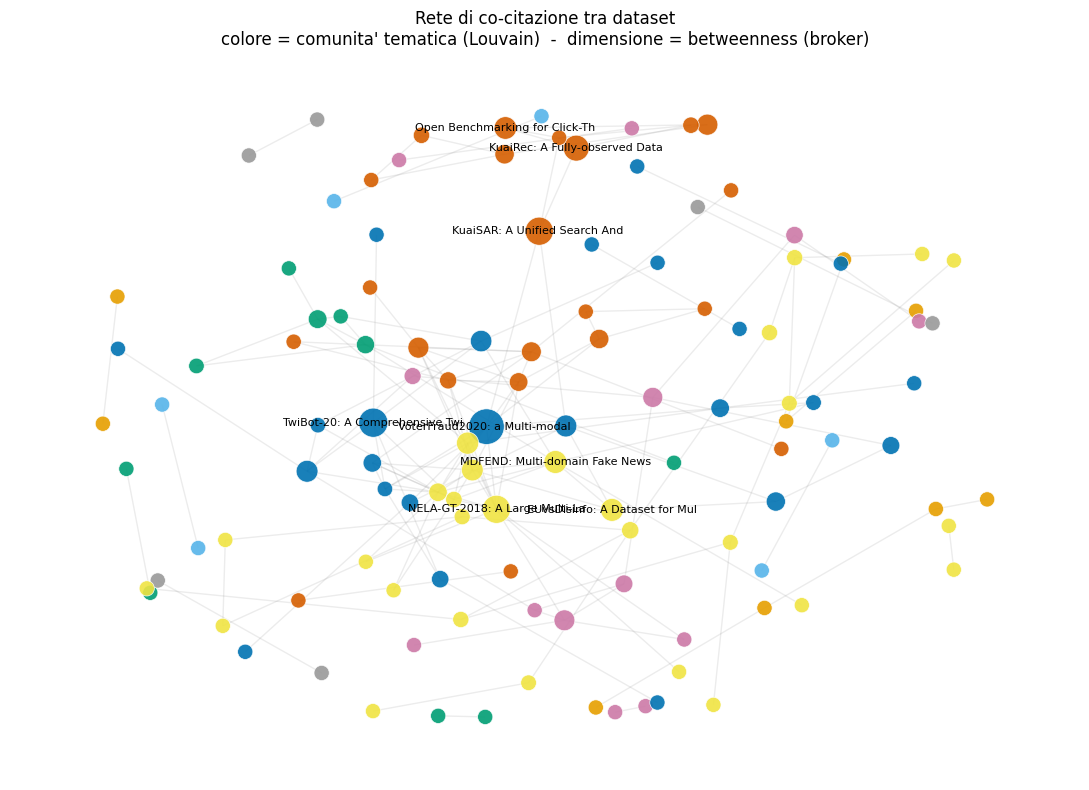

In [ ]:
# ==============================================================================
# MODULO 6.1: VISUALIZZAZIONE INLINE DELLA RETE (co-citazione tra dataset)
# ==============================================================================
# Nessun export verso Gephi: disegno la rete DENTRO il notebook.
# Due dataset sono collegati se un paper li cita entrambi (rete di co-citazione).
# Colore  = comunita' tematica (Louvain)
# Size    = betweenness centrality (i dataset-ponte tra comunita')

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

print("[NET-VIZ] Caricamento nodes/edges e costruzione rete di co-citazione...")
df_nodes = pd.read_csv(NODES_CSV_PATH)
df_edges = pd.read_csv(EDGES_CSV_PATH)

dataset_ids = set(df_nodes.loc[df_nodes['Type'] == 'Original Dataset', 'Id'])
label_map   = dict(zip(df_nodes['Id'], df_nodes.get('Label', df_nodes['Id'])))

# Per ogni paper citante collego le coppie di dataset che cita insieme
co_weight = defaultdict(int)
for citer, grp in df_edges.groupby('Source'):
    cited_ds = sorted({t for t in grp['Target'] if t in dataset_ids})
    for a, b in combinations(cited_ds, 2):
        co_weight[(a, b)] += 1

H = nx.Graph()
H.add_nodes_from(dataset_ids)
for (a, b), w in co_weight.items():
    H.add_edge(a, b, weight=w)

# Tolgo i dataset mai co-citati (nodi isolati): non aiutano la lettura del grafo
H.remove_nodes_from(list(nx.isolates(H)))
print(f"  Dataset collegati: {H.number_of_nodes()}  |  archi di co-citazione: {H.number_of_edges()}")

if H.number_of_edges() == 0:
    print("  [WARN] Nessuna co-citazione trovata: niente da disegnare.")
else:
    # Comunita' tematiche (Louvain) e broker (betweenness)
    communities = nx.community.louvain_communities(H, seed=42, weight='weight')
    node2comm   = {n: i for i, comm in enumerate(communities) for n in comm}
    modularity  = nx.community.modularity(H, communities, weight='weight')
    betweenness = nx.betweenness_centrality(H, weight='weight')
    print(f"  Comunita' tematiche (Louvain): {len(communities)}  |  modularita': {modularity:.3f}")

    # Dataset-ponte principali (li etichetto nel grafico)
    top_brokers = sorted(betweenness, key=betweenness.get, reverse=True)[:15]
    print("\n[NET-VIZ] Dataset-ponte principali (betweenness):")
    for r, n in enumerate(top_brokers, 1):
        print(f"  {r}. {str(label_map.get(n, n))[:55]:<55}  btw={betweenness[n]:.3f}  comm={node2comm[n]}")

    # --- Disegno inline: networkx + matplotlib, palette Okabe-Ito (colorblind-safe) ---
    OKABE = ['#0072B2', '#E69F00', '#009E73', '#CC79A7',
             '#56B4E9', '#D55E00', '#F0E442', '#999999']
    pos    = nx.spring_layout(H, seed=42, weight='weight', k=0.5)
    colors = [OKABE[node2comm[n] % len(OKABE)] for n in H.nodes()]
    sizes  = [120 + 4000 * betweenness[n] for n in H.nodes()]

    fig, ax = plt.subplots(figsize=(11, 8))
    nx.draw_networkx_edges(H, pos, alpha=0.15, edge_color='gray', ax=ax)
    nx.draw_networkx_nodes(H, pos, node_color=colors, node_size=sizes,
                           alpha=0.9, linewidths=0.5, edgecolors='white', ax=ax)
    labels = {n: str(label_map.get(n, n))[:30] for n in top_brokers}
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8, ax=ax)

    ax.set_title("Rete di co-citazione tra dataset\n"
                 "colore = comunita' tematica (Louvain)  -  dimensione = betweenness (broker)",
                 fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## Modulo 6.2: Meta-rete delle comunità

Comprimo la rete di co-citazione in una *meta-rete*: ogni comunità tematica individuata da Louvain (§6.1) diventa un singolo nodo, dimensionato in base al numero di dataset che contiene, e gli archi pesati rappresentano le co-citazioni tra comunità diverse. Serve a leggere la macro-struttura tematica del corpus a colpo d'occhio, senza il dettaglio dei singoli dataset.

[META] Ricostruzione della rete di co-citazione...
[META] Comunita': 25  |  collegamenti tra comunita': 11
  C0: twitter, multi, election  (15 dataset)
  C1: measuring, monetary, value  (2 dataset)
  C2: social, multimodal, learning  (6 dataset)
  C3: multi, alignment, image  (2 dataset)
  C4: matches, made, heaven  (2 dataset)
  C5: uqabench, evaluating, user  (2 dataset)
  C6: twitter, isamasred, public  (2 dataset)
  C7: geolink, cruises, non  (2 dataset)
  C8: twitter, social, media  (5 dataset)
  C9: learning, interactive, contrastive  (3 dataset)
  C10: financial, dólares, dollars?  (2 dataset)
  C11: hate, twitter, video  (9 dataset)
  C12: comprehensive, time, series  (2 dataset)
  C13: platform, online, twitter  (11 dataset)
  C14: search, event, generation  (15 dataset)
  C15: twitter, stmhd, extensive  (2 dataset)
  C16: rarebench, can, llms  (2 dataset)
  C17: document, newspaper, doclaynet  (4 dataset)
  C18: wikireddit, tracing, information  (2 dataset)
  C19: scored, pla

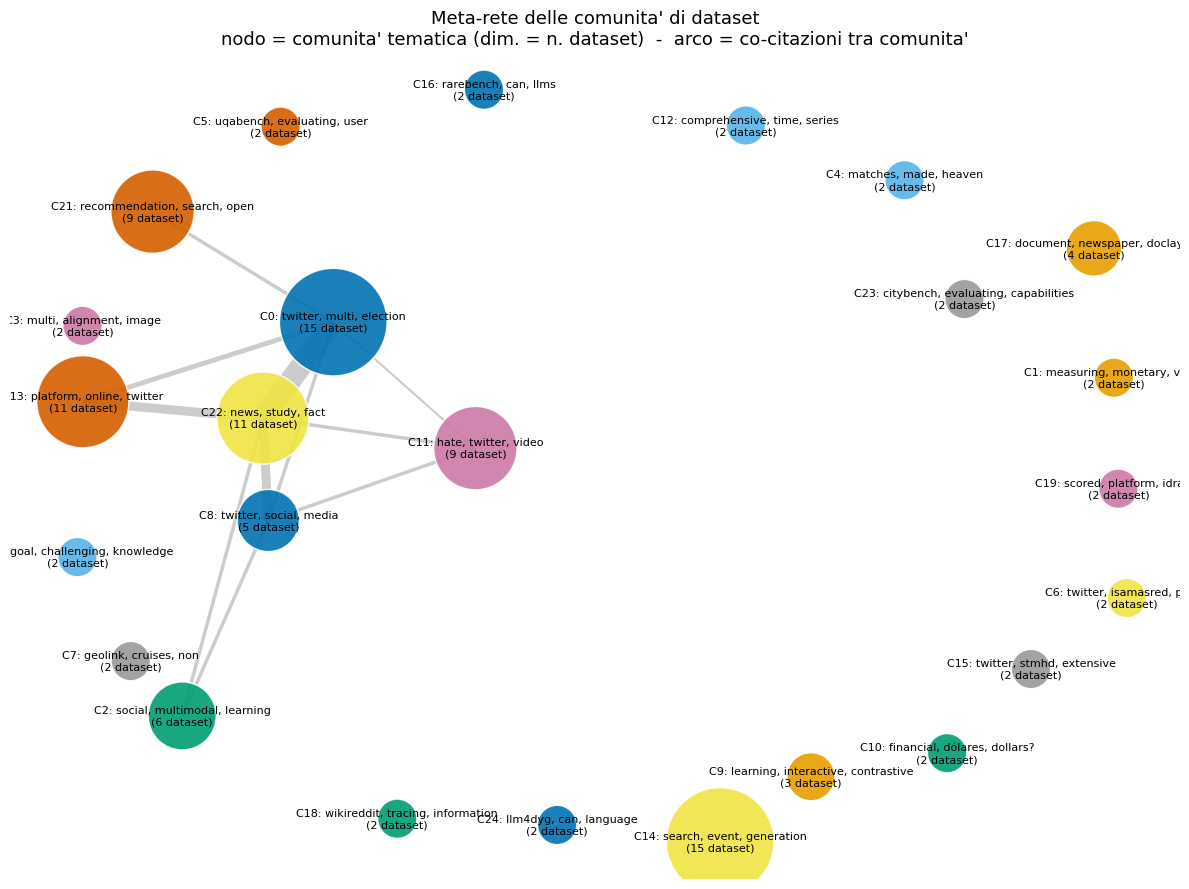

In [ ]:
# ==============================================================================
# MODULO 6.2: META-RETE DELLE COMUNITA' (macro-struttura tematica)
# ==============================================================================
# Comprimo la rete di co-citazione: ogni COMUNITA' Louvain diventa un solo nodo.
# - dimensione nodo = numero di dataset nella comunita'
# - spessore arco   = quante co-citazioni collegano due comunita' diverse
# Serve a leggere la struttura tematica a colpo d'occhio, senza i singoli nodi.

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict, Counter

print("[META] Ricostruzione della rete di co-citazione...")
df_nodes = pd.read_csv(NODES_CSV_PATH)
df_edges = pd.read_csv(EDGES_CSV_PATH)

dataset_ids = set(df_nodes.loc[df_nodes['Type'] == 'Original Dataset', 'Id'])
label_map   = dict(zip(df_nodes['Id'], df_nodes.get('Label', df_nodes['Id'])))

co_weight = defaultdict(int)
for citer, grp in df_edges.groupby('Source'):
    cited_ds = sorted({t for t in grp['Target'] if t in dataset_ids})
    for a, b in combinations(cited_ds, 2):
        co_weight[(a, b)] += 1

H = nx.Graph()
H.add_nodes_from(dataset_ids)
for (a, b), w in co_weight.items():
    H.add_edge(a, b, weight=w)
H.remove_nodes_from(list(nx.isolates(H)))

communities = nx.community.louvain_communities(H, seed=42, weight='weight')
node2comm   = {n: i for i, comm in enumerate(communities) for n in comm}

# --- Costruzione della meta-rete ---
M   = nx.Graph()
dim = {i: len(comm) for i, comm in enumerate(communities)}   # dataset per comunita'
M.add_nodes_from(dim.keys())
for u, v, d in H.edges(data=True):
    cu, cv = node2comm[u], node2comm[v]
    if cu != cv:
        if M.has_edge(cu, cv):
            M[cu][cv]['weight'] += d['weight']
        else:
            M.add_edge(cu, cv, weight=d['weight'])

# --- Etichetta ogni comunita' con le 3 parole piu' frequenti nei titoli ---
stop = {'a','the','of','for','and','with','on','in','to','from','data','dataset',
        'datasets','benchmark','using','via','based','new','large','scale'}
etichette = {}
for i, comm in enumerate(communities):
    parole = ' '.join(str(label_map.get(n, '')) for n in comm).lower().replace(':', ' ').replace('-', ' ').split()
    top    = Counter(w for w in parole if w not in stop and len(w) > 2).most_common(3)
    etichette[i] = f"C{i}: " + ", ".join(w for w, _ in top) + f"\n({dim[i]} dataset)"

print(f"[META] Comunita': {M.number_of_nodes()}  |  collegamenti tra comunita': {M.number_of_edges()}")
for i in sorted(etichette):
    print("  " + etichette[i].replace(chr(10), '  '))

# --- Disegno ---
pos    = nx.spring_layout(M, seed=42, weight='weight', k=1.5)
sizes  = [400 * dim[c] for c in M.nodes()]
widths = [0.5 + M[u][v]['weight'] for u, v in M.edges()]
OKABE  = ['#0072B2','#E69F00','#009E73','#CC79A7','#56B4E9','#D55E00','#F0E442','#999999']
colors = [OKABE[c % len(OKABE)] for c in M.nodes()]

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_edges(M, pos, width=widths, alpha=0.4, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(M, pos, node_size=sizes, node_color=colors,
                       alpha=0.9, edgecolors='white', linewidths=1, ax=ax)
nx.draw_networkx_labels(M, pos, labels=etichette, font_size=8, ax=ax)
ax.set_title("Meta-rete delle comunita' di dataset\n"
             "nodo = comunita' tematica (dim. = n. dataset)  -  arco = co-citazioni tra comunita'",
             fontsize=13)
ax.axis('off'); plt.tight_layout(); plt.show()

In [ ]:
for c in sorted(set(node2comm.values()), key=lambda k:-sum(node2comm[n]==k for n in H)):
    m=[label_map[n] for n in H if node2comm[n]==c]
    print(f"C{c} ({len(m)}): " + " | ".join(str(x)[:32] for x in m))

C0 (15): A Multi-Platform Collection of S | VaxxHesitancy: A Dataset for Stu | TweetIntent@Crisis: A Dataset Re | VoterFraud2020: a Multi-modal Da | A Dataset of Fact-Checked Images | CoVaxxy: A Collection of English | Labeled Datasets for Research on | FaCov: COVID-19 Viral News and R | TwiBot-20: A Comprehensive Twitt | FediData: A Comprehensive Multi- | Characterizing the Use of Images | 3DLNews: A Three-decade Dataset  | ITA-ELECTION-2022: A Multi-Platf | Machine-Made Media: Monitoring t | A Large-Scale Longitudinal Multi
C14 (15): W2E: A Worldwide-Event Benchmark | CC-News-En: A Large English News | CodeGeeX: A Pre-Trained Model fo | ORCAS: 20 Million Clicked Query- | MLM: A Benchmark Dataset for Mul | Event-QA: A Dataset for Event-Ce | FlaCGEC: A Chinese Grammatical E | TianGong-ST: A New Dataset with  | AceKG: A Large-scale Knowledge G | LearningQ: A Large-Scale Dataset | Assessing The Factual Accuracy o | MAEC: A Multimodal Aligned Earni | A Large Test Collection for Enti | A M

## Modulo 6.3: Silos o cross-pollination?

Mi chiedo se i dataset vengano riusati soprattutto *dentro* la stessa conferenza o *tra* conferenze diverse. Classifico ogni arco di co-citazione come intra-conferenza (i due dataset provengono dalla stessa venue) o inter-conferenza e ne calcolo le quote: molti archi inter- indicano una reale contaminazione tematica tra ICWSM, CIKM e KDD.

> Richiede di aver già eseguito la cella §6.1 (grafo `H`, `node2comm`, `betweenness`).

In [ ]:
conf = dict(zip(df_nodes['Id'], df_nodes['Conferenza']))
intra = sum(1 for u, v in H.edges() if conf.get(u) == conf.get(v))
inter = H.number_of_edges() - intra
print(f"Co-citazioni STESSA conferenza:  {intra} ({intra/H.number_of_edges()*100:.0f}%)")
print(f"Co-citazioni TRA conferenze:     {inter} ({inter/H.number_of_edges()*100:.0f}%)")
# tanti archi 'inter' = i dataset di ICWSM/CIKM/KDD si mescolano (cross-pollination)

Co-citazioni STESSA conferenza:  94 (59%)
Co-citazioni TRA conferenze:     65 (41%)


### Assortatività per conferenza

Condenso la stessa domanda in una singola metrica di rete, il coefficiente di assortatività rispetto all'attributo *conferenza*: valori vicini a 0 (o negativi) confermano la cross-pollination, valori vicini a 1 indicano che ogni dataset resta nel silo della propria conferenza.

In [ ]:
nx.set_node_attributes(H, conf, 'Conferenza')
r = nx.attribute_assortativity_coefficient(H, 'Conferenza')
print(f"Assortatività per conferenza: {r:.2f}")
# ~0 o negativo → co-citazioni tra conferenze diverse (cross-pollination)
# vicino a 1  → ogni dataset resta nel silo della sua conferenza

Assortatività per conferenza: 0.36


## Modulo 6.4: Etichettatura tematica delle comunità

Assegno un'etichetta interpretabile a ciascuna comunità di Louvain estraendo le parole più frequenti nei titoli dei dataset che la compongono. Trasformo così i cluster numerici in famiglie tematiche leggibili (ad esempio raccomandazione, disinformazione, dati conversazionali).

In [ ]:
from collections import Counter
stop = {'a','the','of','for','and','with','on','in','to','from','data','dataset','datasets','benchmark','using','via','based'}
label = dict(zip(df_nodes['Id'], df_nodes['Label']))
for c in sorted(set(node2comm.values())):
    membri = [n for n in H.nodes() if node2comm[n] == c]
    parole = ' '.join(str(label.get(n,'')) for n in membri).lower().replace(':',' ').replace('-',' ').split()
    top = Counter(w for w in parole if w not in stop and len(w) > 2).most_common(4)
    print(f"Comunità {c} ({len(membri)} dataset): {', '.join(w for w,_ in top)}")

Comunità 0 (15 dataset): twitter, multi, media, 2022
Comunità 1 (2 dataset): many, ways, lonely, fine
Comunità 2 (6 dataset): multimodal, twitter, social, learning
Comunità 3 (2 dataset): alignment, multi, benchmarking, challenges
Comunità 4 (2 dataset): matches, made, heaven, toolkit
Comunità 5 (2 dataset): uqabench, evaluating, user, embedding
Comunità 6 (2 dataset): twitter, covid19, discourse, analysis
Comunità 7 (2 dataset): geolink, cruises, non, synthetic
Comunità 8 (5 dataset): language, twitter, social, media
Comunità 9 (3 dataset): learning, interactive, contrastive, self
Comunità 10 (2 dataset): financial, dólares, dollars?, unraveling
Comunità 11 (9 dataset): hate, video, youtube, online
Comunità 12 (2 dataset): time, series, comprehensive, advancing
Comunità 13 (11 dataset): online, platform, network, discourse
Comunità 14 (15 dataset): large, event, search, scale
Comunità 15 (2 dataset): beyond, positive, emotion, deconstructing
Comunità 16 (2 dataset): companykg, large, 

## Modulo 6.5: Densità e frammentazione della rete

Quantifico l'osservazione qualitativa secondo cui la rete di co-citazione è rada: calcolo densità, numero di componenti connesse e dimensione della componente più grande. Numeri bassi confermano che il riuso congiunto di dataset è concentrato attorno a pochi hub e non forma un unico blocco denso.

In [ ]:
print(f"Densità della rete:      {nx.density(H):.3f}")
print(f"Componenti connesse:     {nx.number_connected_components(H)}")
comp = max(nx.connected_components(H), key=len)
print(f"Componente più grande:   {len(comp)} dataset su {H.number_of_nodes()}")

Densità della rete:      0.023
Componenti connesse:     19
Componente più grande:   66 dataset su 118


## Modulo 6.6: I dataset-ponte sono anche i più citati?

Incrocio la betweenness centrality (i dataset che fanno da *ponte* tra comunità) con le citazioni globali di ciascun dataset. Lo scatter mostra se centralità strutturale e popolarità coincidono, oppure se esistono dataset molto citati ma tematicamente isolati e viceversa.

In [ ]:
import pandas as pd
gc = dict(zip(df_nodes['Id'], df_nodes['Global_Citations']))
dfb = pd.DataFrame({'Betweenness':[betweenness[n] for n in H.nodes()],
                    'Citazioni':[gc.get(n,0) for n in H.nodes()],
                    'Label':[str(label.get(n,''))[:30] for n in H.nodes()]})
px.scatter(dfb, x='Betweenness', y='Citazioni', hover_name='Label',
           title='Dataset-ponte vs popolarità').show()

## Modulo 6.7: Export della rete di co-citazione per Gephi

Salvo la rete di co-citazione in formato `.gexf` (apribile direttamente in Gephi) e come coppia di CSV nodi/archi, con comunità, betweenness e grado già annotati sui nodi. Consente l'analisi e il layout interattivo della rete al di fuori del notebook.

In [ ]:
# ==============================================================================
# MODULO 6.7: EXPORT DELLA RETE DI CO-CITAZIONE PER GEPHI
# ==============================================================================
# Rete: nodi = dataset, arco (pesato) se due dataset sono citati insieme.
# Esporto .gexf (apribile direttamente in Gephi) + due CSV (nodi/archi).
import os
import networkx as nx
import pandas as pd
from itertools import combinations
from collections import defaultdict

print("[EXPORT] Ricostruzione della rete di co-citazione...")
df_nodes = pd.read_csv(NODES_CSV_PATH)
df_edges = pd.read_csv(EDGES_CSV_PATH)

dataset_ids = set(df_nodes.loc[df_nodes['Type'] == 'Original Dataset', 'Id'])
label_map   = dict(zip(df_nodes['Id'], df_nodes.get('Label', df_nodes['Id'])))

co_weight = defaultdict(int)
for citer, grp in df_edges.groupby('Source'):
    cited_ds = sorted({t for t in grp['Target'] if t in dataset_ids})
    for a, b in combinations(cited_ds, 2):
        co_weight[(a, b)] += 1

H = nx.Graph()
H.add_nodes_from(dataset_ids)
for (a, b), w in co_weight.items():
    H.add_edge(a, b, weight=w)
H.remove_nodes_from(list(nx.isolates(H)))
print(f"  Dataset collegati: {H.number_of_nodes()}  |  archi: {H.number_of_edges()}")

# Comunita' (Louvain) + betweenness, salvate come attributi dei nodi
communities = nx.community.louvain_communities(H, seed=42, weight='weight')
node2comm   = {n: i for i, c in enumerate(communities) for n in c}
betweenness = nx.betweenness_centrality(H, weight='weight')
for n in H.nodes():
    H.nodes[n]['Label']       = str(label_map.get(n, n))
    H.nodes[n]['Community']   = int(node2comm[n])
    H.nodes[n]['Betweenness'] = float(round(betweenness[n], 5))
    H.nodes[n]['Degree']      = int(H.degree(n))

# --- 1) GEXF: file singolo, lo apri con File > Open in Gephi ---
gexf_path = os.path.join(BASE_DIR, '06_cocitation_network.gexf')
nx.write_gexf(H, gexf_path)

# --- 2) CSV: in alternativa, da importare nella Data Laboratory ---
nodes_out = pd.DataFrame([{'Id': n,
                           'Label':       H.nodes[n]['Label'],
                           'Community':   H.nodes[n]['Community'],
                           'Betweenness': H.nodes[n]['Betweenness'],
                           'Degree':      H.nodes[n]['Degree']} for n in H.nodes()])
edges_out = pd.DataFrame([{'Source': u, 'Target': v, 'Weight': d['weight'], 'Type': 'Undirected'}
                          for u, v, d in H.edges(data=True)])
nodes_csv = os.path.join(BASE_DIR, '06_cocitation_nodes.csv')
edges_csv = os.path.join(BASE_DIR, '06_cocitation_edges.csv')
nodes_out.to_csv(nodes_csv, index=False)
edges_out.to_csv(edges_csv, index=False)

print("\n[EXPORT] Salvati per Gephi:")
print(f"  GEXF : {gexf_path}")
print(f"  Nodi : {nodes_csv}")
print(f"  Archi: {edges_csv}")

[EXPORT] Ricostruzione della rete di co-citazione...
  Dataset collegati: 118  |  archi: 159

[EXPORT] Salvati per Gephi:
  GEXF : /content/drive/MyDrive/ScrapingDBLP_final/06_cocitation_network.gexf
  Nodi : /content/drive/MyDrive/ScrapingDBLP_final/06_cocitation_nodes.csv
  Archi: /content/drive/MyDrive/ScrapingDBLP_final/06_cocitation_edges.csv


# Modulo 7: Data Citation Advantage — Analisi statistica

In questa fase metto alla prova un'ipotesi classica della scientometria: il **Data Citation Advantage (DCA)**, ovvero l'idea che i paper che rilasciano dati ottengano più citazioni di quelli che non lo fanno. La formulazione originale di Piwowar et al. (2007) dice precisamente: *a parità di tutto il resto*, condividere i dati porta a un surplus di citazioni.

### Cosa misuro qui (e cosa NON misuro)
Sono onesta con i limiti: nel mio dataset NON ho un'osservazione diretta di "questo paper ha condiviso i dati / questo no". Ho però una proxy: tramite il classificatore NLP del Modulo 2.6 posso etichettare ogni paper come "Con Dataset" (paper il cui contributo è un dataset) o "Senza Dataset" (tutti gli altri). Questi due gruppi *non sono direttamente equivalenti* alla dicotomia originale del DCA (che confronta paper della stessa tipologia con e senza dati condivisi), ma forniscono un proxy ragionevole.

### Articolazione dell'analisi
* **7.1** Confronto volumi anno per anno.
* **7.2** Effetto maturazione: medie e **mediane** (importante perché le citazioni hanno distribuzione fortemente asimmetrica).


## 7.1 Volumi di pubblicazione: Con Dataset vs Senza Dataset

Per separare i due gruppi riapplico la logica del Modulo 3.5 (NLP) all'intero Silver Layer. Tutto ciò che il filtro NLP avrebbe promosso al Gold lo etichetto come "Con Dataset"; tutto il resto come "Senza Dataset". Il grafico a barre affiancate mostra l'evoluzione dei volumi anno per anno.


In [ ]:
# ==============================================================================
# 7.1: CONFRONTO VOLUMI (CON VS SENZA DATASET)
# ==============================================================================
import pandas as pd
import plotly.express as px

print("[DCA] Caricamento del Silver Layer NLP e tagging Con/Senza Dataset...")
df_silver_nlp = pd.read_csv(SILVER_NLP_CSV_PATH)

# Pulizia: rimuovo record privi di abstract (non hanno fornito segnale al modello)
df_clean = df_silver_nlp.dropna(subset=['Abstract_Snippet']).copy()
df_clean = df_clean[df_clean['Abstract_Snippet'].astype(str).str.strip() != '']
df_clean = df_clean[df_clean['Abstract_Snippet'] != 'N/A']


def tag_dataset_papers_nlp(df: pd.DataFrame) -> pd.Series:
    """Stessa logica del Modulo 3.5: high/moderate confidence + blacklist editoriale."""
    is_data_or_resource_track = df['Categoria'].isin(['Dataset Track', 'Resource/Tools Track'])
    escluse                   = ['Keynotes & Tutorials', 'Demo Papers', 'Poster Papers']
    not_excluded_track        = ~df['Categoria'].isin(escluse)

    high_confidence              = df['NLP_Dataset_Probability'] >= 0.65
    moderate_confidence_supported = (df['NLP_Dataset_Probability'] >= 0.50) & is_data_or_resource_track

    return not_excluded_track & (high_confidence | moderate_confidence_supported)


df_clean['Tipo_Paper'] = 'Senza Dataset'
df_clean.loc[tag_dataset_papers_nlp(df_clean), 'Tipo_Paper'] = 'Con Dataset'

print(f"  Totale paper validi:   {len(df_clean)}")
print(f"  Con Dataset:           {(df_clean['Tipo_Paper']=='Con Dataset').sum()}")
print(f"  Senza Dataset:         {(df_clean['Tipo_Paper']=='Senza Dataset').sum()}")

# --- Grafico volumi per anno ---
dist_anni = df_clean.groupby(['Anno', 'Tipo_Paper']).size().reset_index(name='Numero_Paper')

fig_vol = px.bar(
    dist_anni,
    x='Anno', y='Numero_Paper', color='Tipo_Paper', barmode='group',
    title='Volumi di Pubblicazione: Con Dataset vs Senza Dataset (NLP-tagged)',
    labels={'Numero_Paper': 'Numero di Paper'},
    color_discrete_sequence=BINARY_COLORS,
    template='plotly_white'
)
fig_vol.update_layout(xaxis=dict(dtick=1), height=500)
fig_vol.show()


[DCA] Caricamento del Silver Layer NLP e tagging Con/Senza Dataset...
  Totale paper validi:   11517
  Con Dataset:           434
  Senza Dataset:         11083


## 7.2 Effetto maturazione: medie *e* mediane

Le citazioni richiedono anni per accumularsi. Per isolare l'effetto reale confronto due orizzonti temporali:
* **Tutti gli anni**: media calcolata sull'intero dataset (le code recenti la deprimono).
* **Storico (≤ 2023)**: solo paper con almeno 2 anni di maturazione, per dare a entrambi i gruppi il tempo di accumulare citazioni.

Mostro **media e mediana**: con distribuzioni di citazioni così asimmetriche (power-law), la mediana è una misura di tendenza centrale più affidabile, perché non viene distorta dai pochi blockbuster citazionali.


In [ ]:
# ==============================================================================
# 7.2: EFFETTO MATURAZIONE (MEDIE + MEDIANE)
# ==============================================================================
print("[DCA] Calcolo medie e mediane sui due orizzonti temporali...")

df_storico = df_clean[df_clean['Anno'] <= 2023]

# --- Medie ---
media_all = df_clean.groupby('Tipo_Paper')['Citazioni'].agg(['mean', 'median', 'count']).round(2)
media_sto = df_storico.groupby('Tipo_Paper')['Citazioni'].agg(['mean', 'median', 'count']).round(2)

print("\n[DCA] Tutti gli anni:")
print(media_all.to_string())

print("\n[DCA] Storico (Anno <= 2023):")
print(media_sto.to_string())

# --- Visualizzazione ---
media_all_long = media_all.reset_index().melt(
    id_vars='Tipo_Paper',
    value_vars=['mean', 'median'],
    var_name='Metrica', value_name='Valore'
)
media_all_long['Periodo'] = 'Tutti gli anni'
media_sto_long = media_sto.reset_index().melt(
    id_vars='Tipo_Paper',
    value_vars=['mean', 'median'],
    var_name='Metrica', value_name='Valore'
)
media_sto_long['Periodo'] = 'Storico (<=2023)'

df_plot = pd.concat([media_all_long, media_sto_long])
df_plot['Metrica'] = df_plot['Metrica'].replace({'mean': 'Media', 'median': 'Mediana'})

fig_mat = px.bar(
    df_plot,
    x='Tipo_Paper', y='Valore', color='Periodo',
    facet_col='Metrica',
    barmode='group', text_auto='.1f',
    title="Data Citation Advantage: Media vs Mediana, totale vs storico",
    template='plotly_white',
    color_discrete_sequence=BINARY_COLORS
)
fig_mat.update_traces(textfont_size=12, textposition='outside', cliponaxis=False)
fig_mat.update_layout(height=500)
# Asse Y INDIPENDENTE per ogni pannello: media (~880) e mediana (~12) hanno scale
# molto diverse; senza questo la mediana viene schiacciata a zero e diventa
# illeggibile. Cosi' ogni facet ha la sua scala leggibile.
fig_mat.update_yaxes(matches=None, showticklabels=True)
fig_mat.show()


[DCA] Calcolo medie e mediane sui due orizzonti temporali...

[DCA] Tutti gli anni:
                 mean  median  count
Tipo_Paper                          
Con Dataset     18.05     3.0    434
Senza Dataset  651.36     7.0  11083

[DCA] Storico (Anno <= 2023):
                 mean  median  count
Tipo_Paper                          
Con Dataset     32.18    12.0    225
Senza Dataset  883.41    12.0   8160
